#TP 3

# TP3: Reconnaissance de signaux de communication par apprentissage profond

<div class=consignes> Listez les noms des étudiants (2 au maximum) ayant participé à ce notebook dans la cellule suivante (prénom, nom).<br/>
Au moment du rendu, le notebook doit être nommé nom1_nom2_dlts_tp3.ipynb

2 séances de TP sur ce sujet : le 6 novembre (1h00), le 13 novembre (3h).
Le cours du 19 novembre sera partagé en 3 : cours sur la séparation de sources audio / présentation des mini projets et organisation des soutenances / fin de ce TP.<br>
Deadline pour le rendu du TP: 26 novembre 2024, 13h59, par mail à deepetsignal.mva@gmail.com <br>

Pour installer les paquets nécessaires à la réalisation de ce TP vous pouvez utiliser dans le notebook
    
```
!pip install \< nom_du_paquet \>
```
merci de regrouper toutes les installations dans la première cellule du notebook.
Essayez de faire en sorte que votre notebook puisse se lire comme un compte rendu, évitez de laisser du code mort et prennez le temps de commenter vos observations et résultats.

## Problématique

On cherche à identifier un type d'émetteur de communication à partir de l'observation d'un signal provenant de l'émetteur
de 2048 échantillons IQ (In Phase / Quadrature) ie le signal prend des valeurs complexes. On représente la partie
réelle et la partie imaginaire du signal par deux canaux réel d'un signal multivarié.

L'émetteur peut provenir de 6 catégories différentes.
Les paramètres différenciant les différentes catégories sont
- le type de modulation
- la présence ou non de séquences pilotes et le cas échéant la structure de trame pilotes / données
- le débit de la transmission

Les signaux se propagent en champs libre et sont enregistrés par une antenne. Le signal reçu est transposé en bande de base c'est à dire que si le signal est transmis autour d'une fréquence centrale f0, une première étape de traitement du signal à la réception recentre le signal autour de la fréquence 0.


Les différents signaux observés dans ce TP sont entachés de différentes erreurs caractéristiques de la propagation
électromagnétique comme :
- modification aléatoire de la phase du signal lors de la transmission
- imperfection de la transposition en bande de base qui laisse le signal transposé à une fréquence df0 << f0
- présence d'interférence entre les symboles transmis (dûes par exemple à plusieurs chemins de propagation)
- présence d'un bruit blanc additif gaussien

Le niveau du bruit relativement à celui du signal utile est décrit par le SNR (Signal to Noise Ratio) et exprimé en dB. On suppose que le SNR est connu lors de l'acquisition d'un signal. Lors de ce TP nous rencontrerons 4 niveaux de SNR: 30 dB (facile), 20 dB, 10 dB et 0 dB (en espérant qu'on puisse faire quelque chose de ces données).
Un de nos objectifs sera de qualifier la performance des algorithmes mis en place en fonction du SNR.

Les objectifs de ce TP sont:

1. Définir une ou plusieurs architectures de réseaux de neurones profonds et les implémenter en PyTorch
2. Entrainer ces architectures, la fonction de perte employée pourra être la log vraisemblance négative: https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html.
3. Qualifier les performances de votre réseau de neurones sur l'ensemble de test via:
   - Le calcul de l'accuracy implémentée par exemple dans le package TorchMetrics (https://torchmetrics.readthedocs.io/en/stable/classification/accuracy.html)
   - La réalisation d'un graphique accuracy vs SNR
   - La réalisation des matrices de confusion entre les différentes classes pour les différents SNR (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
4. Rapporter les performances de vos architectures à leur complexité, la complexité d'un réseau de neurones étant ici résumé au nombre de paramètres libres qu'il fait intervenir

Durant l'entraînement on observera l'évolution de la fonction de perte et de l'accuracy sur l'ensemble d'entraînement et sur l'ensemble de validation.


Les 4 premières parties sont un échauffement sur lequel vous pouvez passer vite si vous êtes à l'aise avec le sujet.
Le gros du travail est dans la partie 5 "Entraînemenent d'un réseau de neurones".

Surtout privilégiez dans un premier temps la simplicité quitte à complexifier votre approche ensuite pour doper ses performances. Ne restez pas bloqué sur des réseaux qui "mettent trop de temps à apprendre"

**NAME : Eliott Vigier & Victor Guichard**

In [ ]:
import numpy as np
import torch
import h5py # pour gérer les formats de données utilisés ici
import matplotlib.pyplot as plt

# Data

In this section we will create some helper function to load our dataset and load the data.We will then visualize our data distribution.

In [ ]:
def get_labels(open_h5_file):
    return {
        open_h5_file['label_name'].attrs[k] : k
        for k in open_h5_file['label_name'].attrs.keys()
    }

def load_dataset(h5_file_path):
    data = h5py.File(h5_file_path , 'r')
    label_mapping = get_labels(data)

    signals = np.array(data['signaux'])
    snr = np.array(data['snr'])
    labels_ids = np.array(data['labels'])

    data.close()

    return signals, snr, labels_ids, label_mapping


TRAIN_PATH = "train.hdf5"
VALIDATION_PATH = "validation.hdf5"
TEST_PATH = "test.hdf5"

train_signals, train_snr, train_labels, label_mapping = load_dataset(TRAIN_PATH)
eval_signals, eval_snr, eval_labels, _ = load_dataset(VALIDATION_PATH)
test_signals, test_snr, test_labels, _ = load_dataset(TEST_PATH)

## Distribution

### Class Distribution

This can be useful to detect class imbalances. In this case, all sets are properly balanced.

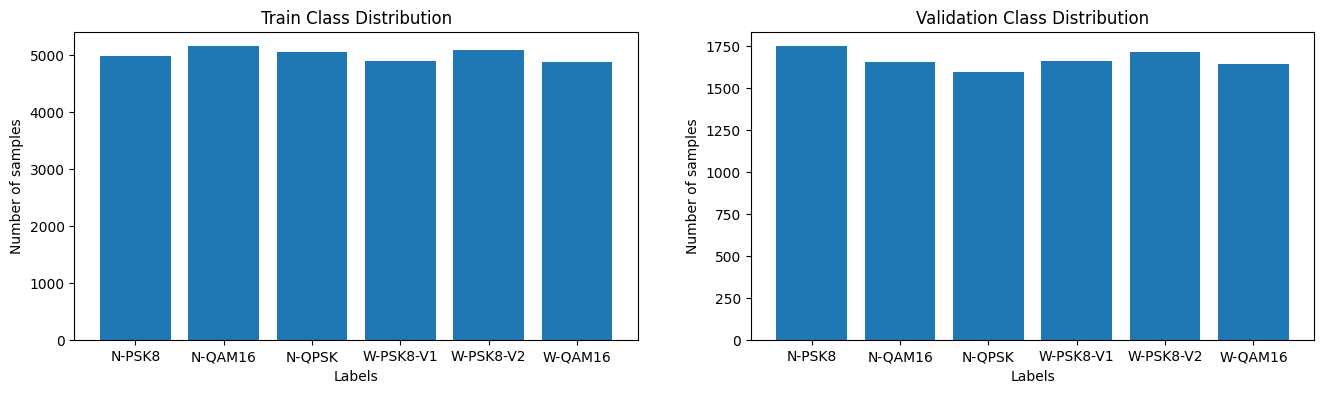

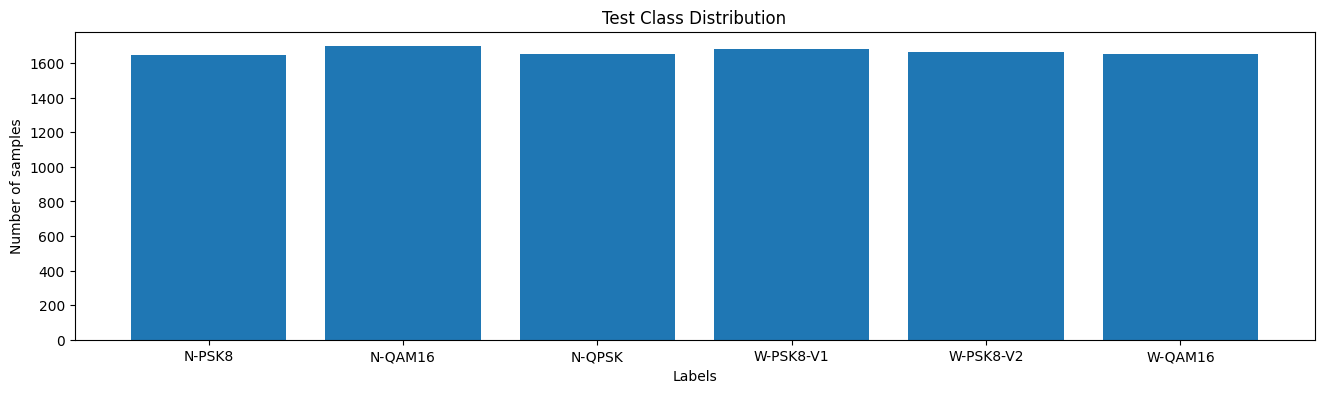

In [ ]:
def plot_class_distribution(signals, labels, ax=None, title="Distribution of classes"):
    unique_labels, labels_count = np.unique(labels, return_counts=True)
    if ax is None:
        plt.bar(unique_labels, labels_count)
        plt.xlabel("Labels")
        plt.ylabel("Number of samples")
        plt.title(title)
        plt.show()
    else:
        ax.bar(unique_labels, labels_count)
        ax.set_xlabel("Labels")
        ax.set_ylabel("Number of samples")
        ax.set_title(title)


f, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_class_distribution(train_signals, np.vectorize(label_mapping.get)(train_labels), axes[0], title="Train Class Distribution")
plot_class_distribution(eval_signals, np.vectorize(label_mapping.get)(eval_labels), axes[1], title="Validation Class Distribution")
plt.figure(figsize=(16, 4))
plot_class_distribution(test_signals, np.vectorize(label_mapping.get)(test_labels), None, title="Test Class Distribution")

## Distribution

### SNR Distribution

This can also be useful to detect imbalances. In this case, all sets are properly balanced.

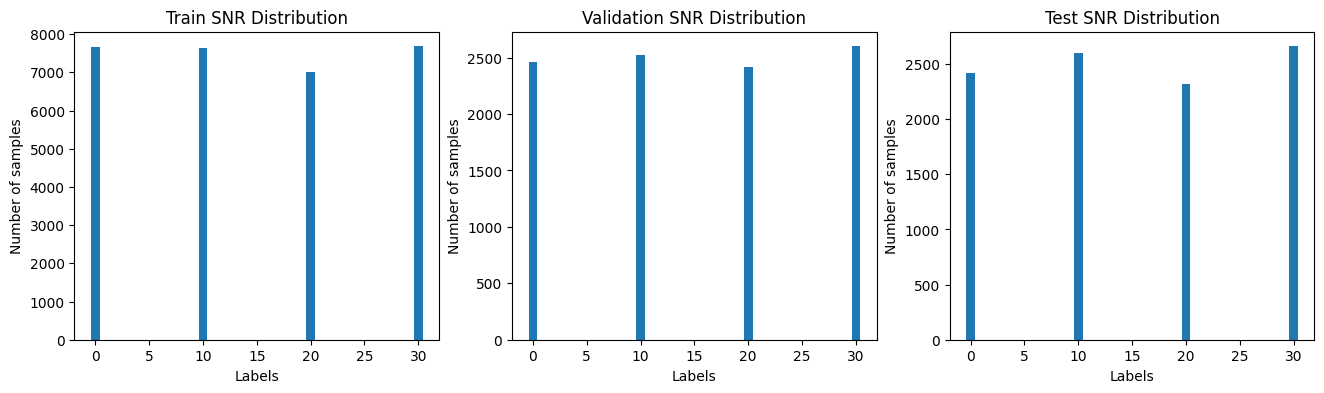

In [ ]:
def plot_snr_distribution(signals, snr, ax=None, title="Distribution of classes"):
    unique_snr, snr_count = np.unique(snr, return_counts=True)
    if ax is None:
        plt.bar(unique_snr, snr_count)
        plt.xlabel("Labels")
        plt.ylabel("Number of samples")
        plt.title(title)
        plt.show()
    else:
        ax.bar(unique_snr, snr_count)
        ax.set_xlabel("Labels")
        ax.set_ylabel("Number of samples")
        ax.set_title(title)


f, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_snr_distribution(train_signals, train_snr, axes[0], title="Train SNR Distribution")
plot_snr_distribution(eval_signals, eval_snr, axes[1], title="Validation SNR Distribution")
plot_snr_distribution(test_signals, test_snr, axes[2], title="Test SNR Distribution")

## Visualisation

We will visualise the data as a scatter plot where the X dimension is the real part and the Y dimension will be the complex part

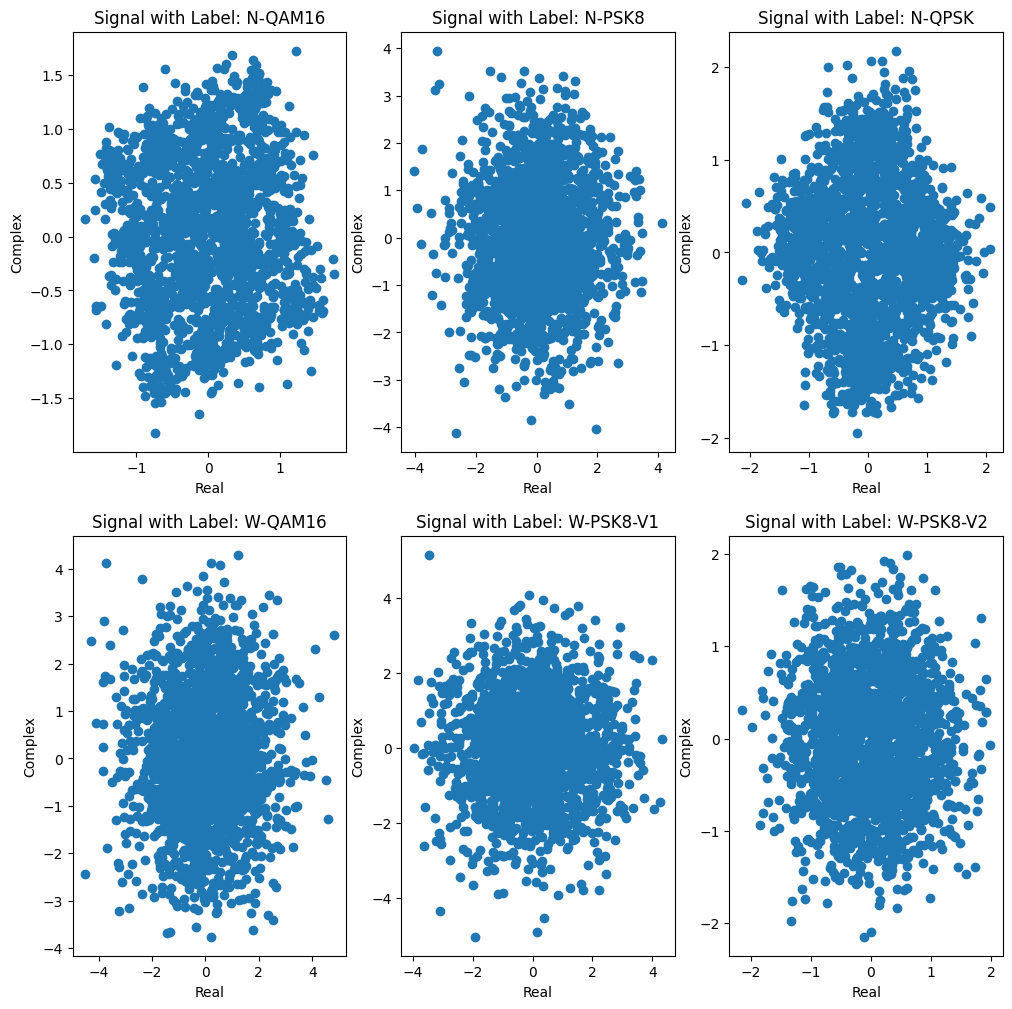

In [ ]:
f, axes = plt.subplots(2, 3, figsize=(12, 12))
for i in range(2):
    for j in range(3):
        idx = np.where(train_labels == (i * 3 + j))[0][0]
        axes[i, j].scatter(train_signals[idx, :, 0], train_signals[idx, :, 1])
        axes[i, j].set_xlabel("Real")
        axes[i, j].set_ylabel("Complex")
        axes[i, j].set_title(f"Signal with Label: {label_mapping[i * 3 + j]}")


# Data Loading

In [ ]:
NUM_CLASSES = 6
SIGNAL_LENGTH = 2048
SIGNAL_DEPTH = 2

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, path_to_data):
        with h5py.File(path_to_data, 'r') as data:
          self.signals = np.array(data['signaux'])
          self.snr = np.array(data['snr'])
          self.labels_id = np.array(data['labels'])

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signals = self.signals[idx]
        snr = self.snr[idx]
        labels_id = self.labels_id[idx]
        return signals, snr, labels_id

# Simple Model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleModel(nn.Module):
  def __init__(self, input_channels=SIGNAL_DEPTH, signal_length=SIGNAL_LENGTH, num_classes=NUM_CLASSES):
    super(SimpleModel, self).__init__()

    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(input_channels * signal_length, num_classes)

  def forward(self, x):
    x = self.flatten(x)
    x = self.fc1(x)
    return F.log_softmax(x, dim=1)

# Training

We will define a trainer class that will help us quickly experiment over multiple models.

The trainer will have the following functions:

* train: run the training loop and validation across multiple epochs
* plot training curves: if the trainer was used, we will plot the train and validation metrics
* test: run the inference on the test set and display some metrics

In [ ]:
from dataclasses import dataclass
import os
import sklearn.metrics

device = 'cuda' if torch.cuda.is_available() else 'cpu'

@dataclass
class Config:
    epochs: int = 20
    lr: float = 1e-3
    experiment_dir: str = "experiment"

class Trainer:
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.fitted = False

        self.loss_fn = nn.NLLLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

        os.makedirs(self.config.experiment_dir, exist_ok=True)

    @property
    def best_model_path(self):
        return os.path.join(self.config.experiment_dir, "best_model.pth")

    @staticmethod
    def _train(model, dataloader, optimizer, loss_fn, log_interval=3):
        model.train()
        total_loss = 0.0
        correct = 0

        for idx, (batch_x,_,batch_y) in enumerate(dataloader):

            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            batch_y_pred = model(batch_x)

            loss = loss_fn(batch_y_pred, batch_y.long())
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(batch_y_pred, 1)
            correct += (predicted == batch_y).sum().item()

        # Log the progress
        if idx % log_interval == 0:
            print(f"Train Epoch: {epoch} [{idx * len(batch_x)}/{len(dataloader.dataset)} "
              f"({100. * idx / len(dataloader):.0f}%)]\tLoss: {loss.item():.6f}")

        # Epoch accuracy and average loss
        accuracy = 100. * correct / len(dataloader.dataset)
        avg_loss = total_loss / len(dataloader)
        print(f"\nTrain set: Average Loss: {avg_loss:.6f}, Accuracy: {correct}/{len(dataloader.dataset)} "
            f"({accuracy:.2f}%)")

        return avg_loss, accuracy

    @staticmethod
    def _validate(model, dataloader, loss_fn):
        model.eval()
        total_loss = 0.0
        correct = 0

        with torch.no_grad():
            for idx, (batch_x,_,batch_y) in enumerate(dataloader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                batch_y_pred = model(batch_x)

                loss = loss_fn(batch_y_pred, batch_y.long())
                total_loss += loss.item()

                _, predicted = torch.max(batch_y_pred, 1)
                correct += (predicted == batch_y).sum().item()

        # Average loss and accuracy
        avg_loss = total_loss / len(dataloader)
        accuracy = (correct / len(dataloader.dataset)) * 100
        print(f"Validation set: Average Loss: {avg_loss:.6f}, Accuracy: {correct}/{len(dataloader.dataset)} "
            f"({accuracy:.2f}%)")

        return avg_loss, accuracy

    def train(self, train_loader, valid_loader):
        # Lists for Accuracy and Loss graphs
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        best_val_accuracy = 0.0
        self.fitted = True

        # Training and validation loop
        for epoch in range(1, self.config.epochs + 1):
            # Training step
            print(f"Epoch {epoch}/{self.config.epochs}")
            train_loss, train_accuracy = self._train(self.model, train_loader, self.optimizer, self.loss_fn)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_accuracy)

            # Validation step
            val_loss, val_accuracy = self._validate(self.model, valid_loader, self.loss_fn)

            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_accuracy)

            # Save Model
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                torch.save(model.state_dict(), self.best_model_path)
                print(f"New best model saved with validation accuracy: {best_val_accuracy:.2f}%")
            print("-"*100)

    def plot_training_curves(self):
        if not self.fitted:
            return

        epochs_range = range(1, self.config.epochs + 1)

        # Plot training and validation Loss
        plt.figure(figsize=(12, 6))
        plt.plot(epochs_range, self.train_losses, label='Training Loss')
        plt.plot(epochs_range, self.val_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.show()

        # Plot training and validation Accuracy
        plt.figure(figsize=(12, 6))
        plt.plot(epochs_range, self.train_accuracies, label='Training Accuracy')
        plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.show()

    def load_best_model(self):
        if os.path.exists(self.best_model_path):
            self.model.load_state_dict(torch.load(self.best_model_path))

    def count_n_param(self):
      if os.path.exists(self.best_model_path):
        self.model.load_state_dict(torch.load(self.best_model_path))
        print(sum([p.numel() for p in self.model.parameters()]))


    def test(self, dataloader):
      self.load_best_model()
      self.model.eval()
      total_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_predictions = []
      all_snrs = []

      dataset = dataloader.dataset
      if hasattr(dataset, "labels_id"):
          class_names = list(set(dataset.labels_id))
          class_names = sorted(class_names)
      else:
          raise ValueError("Dataset does not provide class information.")

      snr_accuracies = {}
      snr_labels_predictions = {}

      with torch.no_grad():
          for batch_x, batch_snr, batch_y in dataloader:
              # Move data to device
              batch_x, batch_y = batch_x.to(device), batch_y.to(device)

              # Forward pass
              batch_y_pred = self.model(batch_x)

              # Compute loss
              loss = self.loss_fn(batch_y_pred, batch_y.long())
              total_loss += loss.item()

              # Get predictions
              _, predicted = torch.max(batch_y_pred, 1)
              correct += (predicted == batch_y).sum().item()
              total += batch_y.size(0)

              # Collect labels, predictions, and SNRs
              all_labels.extend(batch_y.cpu().numpy())
              all_predictions.extend(predicted.cpu().numpy())
              all_snrs.extend(batch_snr.numpy())

              # Group by SNR
              for snr, label, pred in zip(batch_snr.numpy(), batch_y.cpu().numpy(), predicted.cpu().numpy()):
                  if snr not in snr_labels_predictions:
                      snr_labels_predictions[snr] = {"labels": [], "predictions": []}
                  snr_labels_predictions[snr]["labels"].append(label)
                  snr_labels_predictions[snr]["predictions"].append(pred)

      # Compute metrics
      accuracy = (correct / total) * 100
      avg_loss = total_loss / len(dataloader)

      # Print test results
      print(f"Test set: Average Loss: {avg_loss:.6f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)")
      print(sklearn.metrics.classification_report(all_labels, all_predictions))

      # Plot overall confusion matrix
      plt.figure(figsize=(16, 8))
      cm = sklearn.metrics.confusion_matrix(all_labels, all_predictions)
      sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=[label_mapping[k] for k in range(NUM_CLASSES)]).plot()
      plt.xlabel("Predicted Labels")
      plt.ylabel("True Labels")
      plt.title("Confusion Matrix")
      plt.show()

      # Accuracy vs SNR plot
      snr_values = sorted(snr_labels_predictions.keys())
      snr_accuracies = []

      for snr in snr_values:
          labels = np.array(snr_labels_predictions[snr]["labels"])
          predictions = np.array(snr_labels_predictions[snr]["predictions"])
          accuracy = np.mean(labels == predictions) * 100
          snr_accuracies.append(accuracy)

          # Plot confusion matrix for each SNR
          cm = sklearn.metrics.confusion_matrix(labels, predictions)
          plt.figure(figsize=(16, 8))
          sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=[label_mapping[k] for k in range(NUM_CLASSES)]).plot()
          plt.xlabel("Predicted Labels")
          plt.ylabel("True Labels")
          plt.title(f"Confusion Matrix for SNR = {snr}")
          plt.show()

      # Plot accuracy vs SNR
      plt.figure(figsize=(10, 6))
      plt.plot(snr_values, snr_accuracies, marker='o')
      plt.xlabel("SNR")
      plt.ylabel("Accuracy (%)")
      plt.title("Accuracy vs SNR")
      plt.grid()
      plt.show()

## Experiment 1: Simple Model

This model will be used to check that our trainer and dataloaders work properly

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = SimpleModel().to(device)
config = Config(experiment_dir="simple_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/20

Train set: Average Loss: 2.131948, Accuracy: 5132/30000 (17.11%)
Validation set: Average Loss: 2.194342, Accuracy: 1716/10000 (17.16%)
New best model saved with validation accuracy: 17.16%
----------------------------------------------------------------------------------------------------
Epoch 2/20

Train set: Average Loss: 1.972809, Accuracy: 7622/30000 (25.41%)
Validation set: Average Loss: 2.304572, Accuracy: 1749/10000 (17.49%)
New best model saved with validation accuracy: 17.49%
----------------------------------------------------------------------------------------------------
Epoch 3/20

Train set: Average Loss: 1.936069, Accuracy: 8237/30000 (27.46%)
Validation set: Average Loss: 2.408698, Accuracy: 1714/10000 (17.14%)
----------------------------------------------------------------------------------------------------
Epoch 4/20

Train set: Average Loss: 1.924586, Accuracy: 8512/30000 (28.37%)
Validation set: Average Loss: 2.480849, Accuracy: 1757/10000 (17.57%)
N

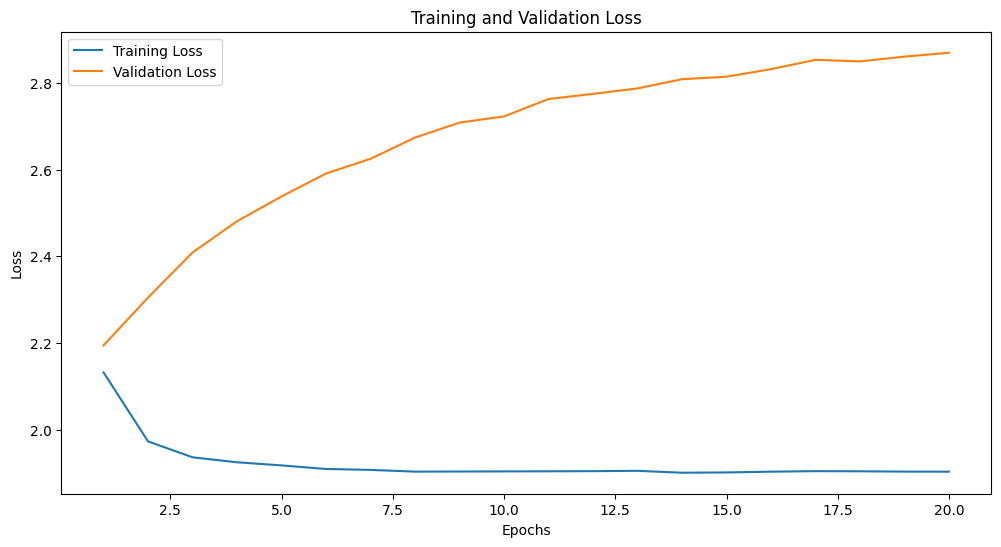

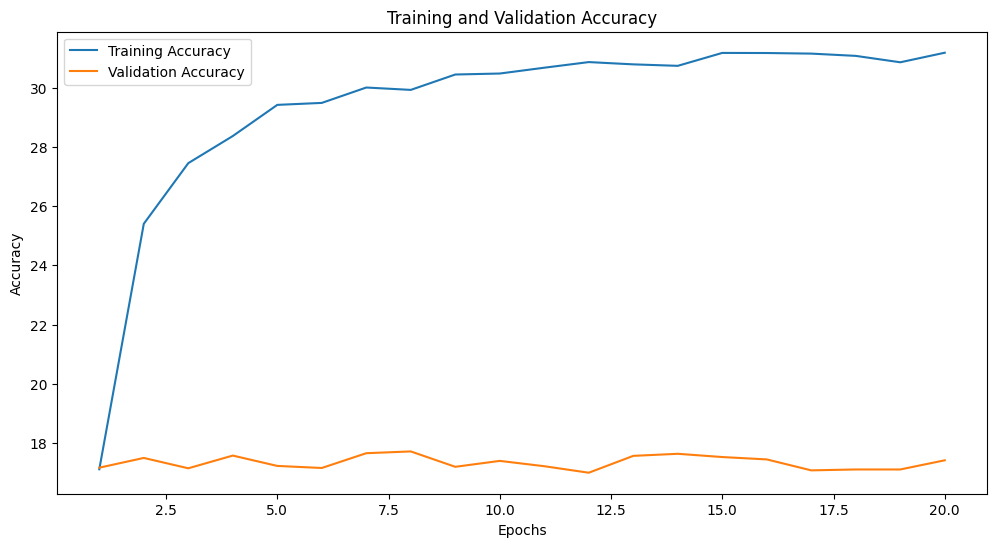

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 2.726392, Accuracy: 1806/10000 (18.06%)
              precision    recall  f1-score   support

           0       0.19      0.21      0.20      1697
           1       0.19      0.19      0.19      1650
           2       0.18      0.17      0.18      1653
           3       0.17      0.16      0.16      1653
           4       0.18      0.17      0.18      1684
           5       0.18      0.18      0.18      1663

    accuracy                           0.18     10000
   macro avg       0.18      0.18      0.18     10000
weighted avg       0.18      0.18      0.18     10000



<Figure size 1600x800 with 0 Axes>

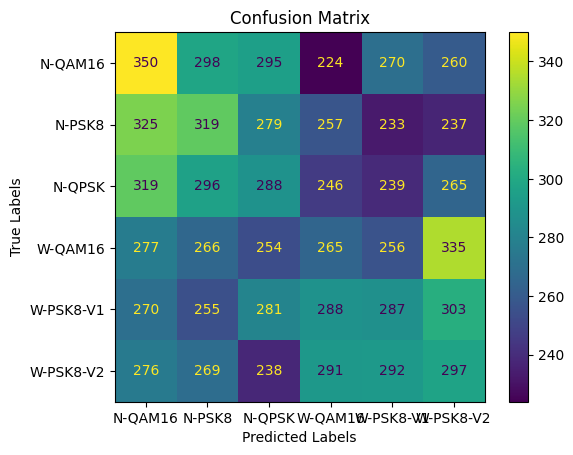

<Figure size 1600x800 with 0 Axes>

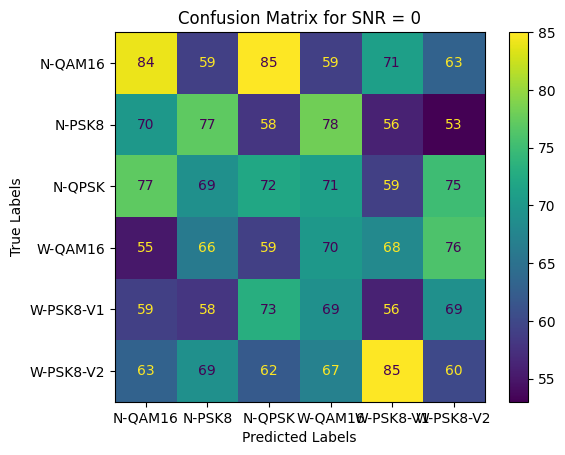

<Figure size 1600x800 with 0 Axes>

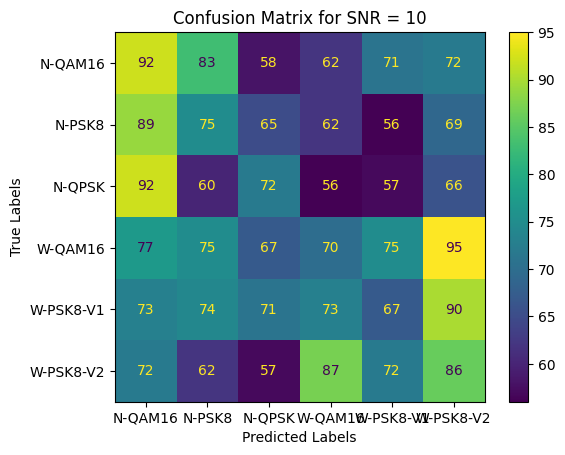

<Figure size 1600x800 with 0 Axes>

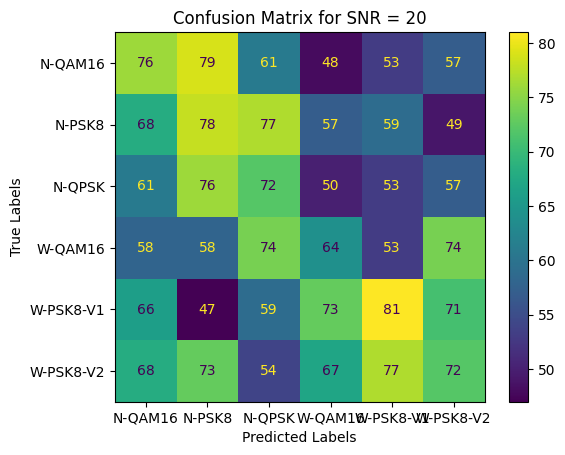

<Figure size 1600x800 with 0 Axes>

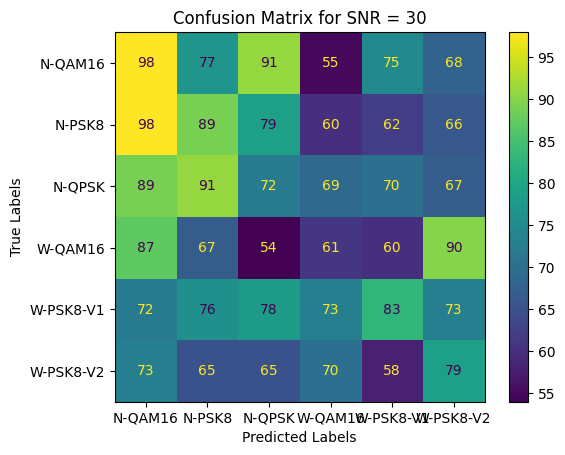

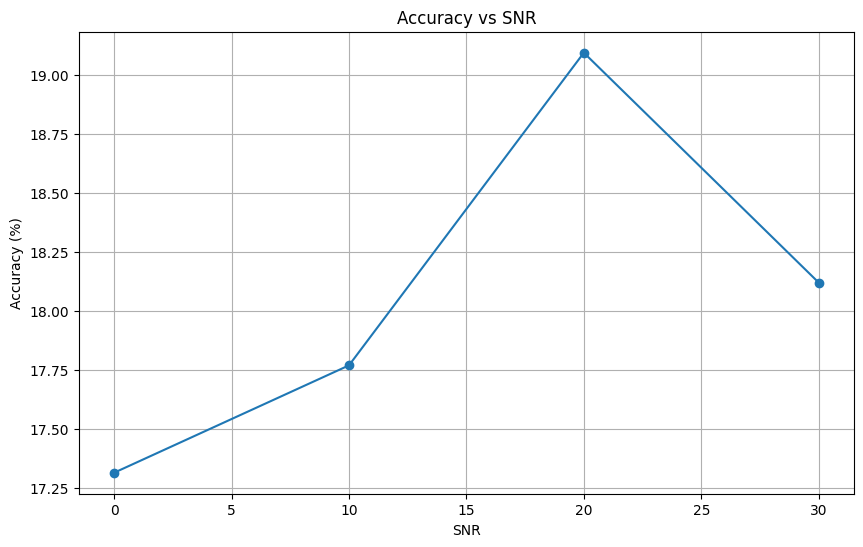

In [ ]:
trainer.test(test_dataloader)

In [ ]:
trainer.count_n_param()

24582


<ipython-input-39-3eb57ac64e45>:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


**Conclusion**: A single linear layer won't be able to identify properly the signals which was expected. However, we were able to validate that our training loop works properly.

Our model has 24,582 parameters, which is more than 10k. Nevertheless, to achieve fewer than 10k parameters given the size of the signals, the resulting model would not be intuitive. Instead, we chose to design a very simple model, which remains close to the desired parameter range.

## Experiment 2: CNN

We will first design a simple CNN model which should get better results than our simple model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool1d(kernel_size=8)
        self.dropout = nn.Dropout(0.5)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * (2048 // 64), 6)

    def forward(self, x):
        # [B, C, T]
        x = torch.transpose(x,1, 2) # [B, T, C]
        x = F.relu(self.conv1(x))  # [B, 64, C]
        x = self.pool(x)          # [B, 64, C/8]
        x = F.relu(self.conv2(x))  # [B, 128, C/8]
        x = self.pool(x)  # [B, 128, C/64]
        x = self.dropout(x)
        # Flatten for fully connected layer
        x = self.flatten(x)        # [B, 128, C/64] -> [B, 128 * C/64]
        x = self.fc(x)             # [B, 6]

        return F.log_softmax(x, dim=1)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = CNNModel().to(device)
config = Config(epochs=50, experiment_dir="cnn_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/50

Train set: Average Loss: 1.190100, Accuracy: 12341/30000 (41.14%)
Validation set: Average Loss: 0.868462, Accuracy: 5626/10000 (56.26%)
New best model saved with validation accuracy: 56.26%
----------------------------------------------------------------------------------------------------
Epoch 2/50

Train set: Average Loss: 0.832396, Accuracy: 16787/30000 (55.96%)
Validation set: Average Loss: 0.718274, Accuracy: 6074/10000 (60.74%)
New best model saved with validation accuracy: 60.74%
----------------------------------------------------------------------------------------------------
Epoch 3/50

Train set: Average Loss: 0.739395, Accuracy: 17605/30000 (58.68%)
Validation set: Average Loss: 0.695814, Accuracy: 5851/10000 (58.51%)
----------------------------------------------------------------------------------------------------
Epoch 4/50

Train set: Average Loss: 0.701392, Accuracy: 18172/30000 (60.57%)
Validation set: Average Loss: 0.660481, Accuracy: 6339/10000 (63.39

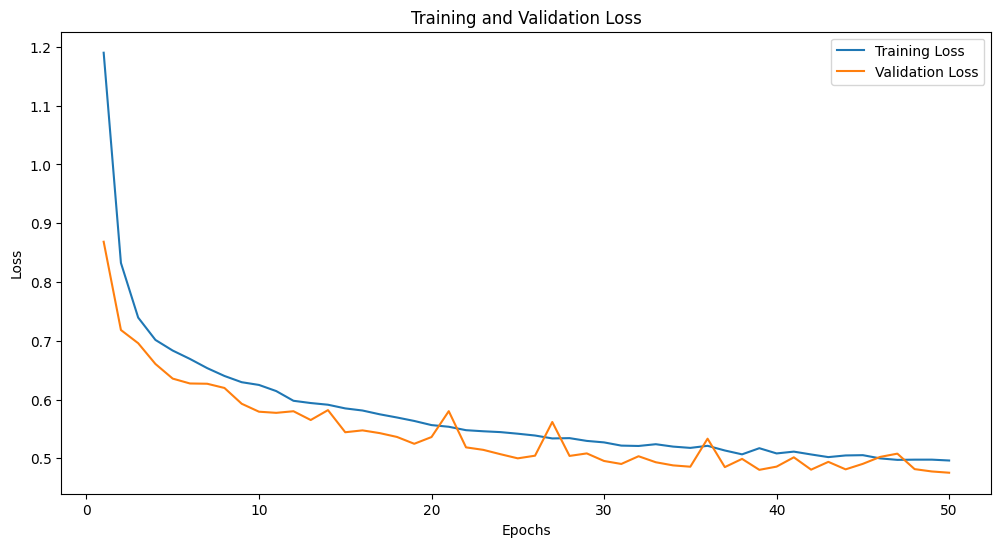

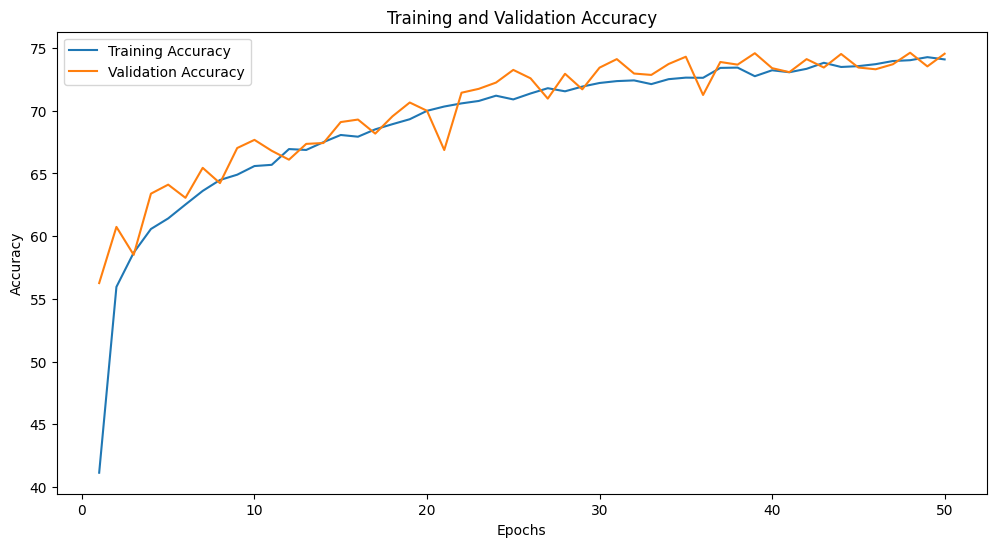

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 0.475096, Accuracy: 7536/10000 (75.36%)
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1697
           1       0.81      0.80      0.81      1650
           2       0.83      0.75      0.79      1653
           3       0.86      0.85      0.86      1653
           4       0.59      0.68      0.63      1684
           5       0.64      0.54      0.59      1663

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



<Figure size 1600x800 with 0 Axes>

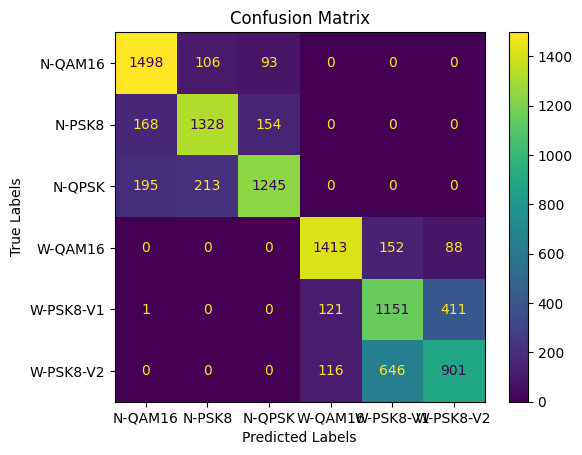

<Figure size 1600x800 with 0 Axes>

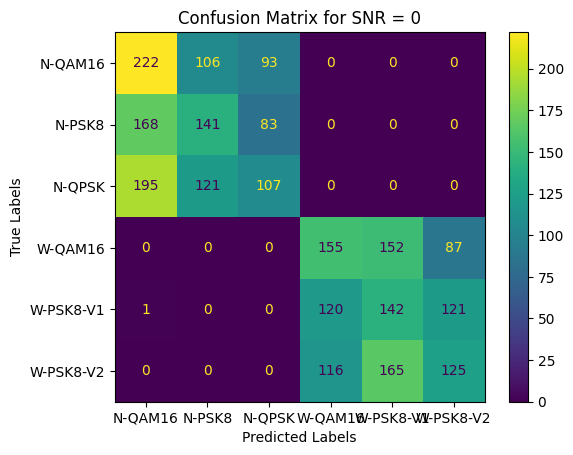

<Figure size 1600x800 with 0 Axes>

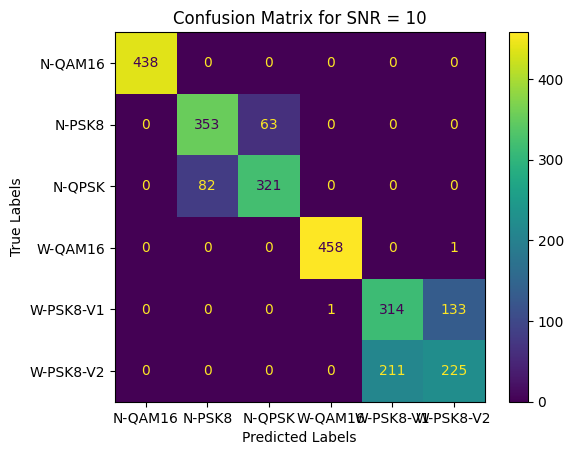

<Figure size 1600x800 with 0 Axes>

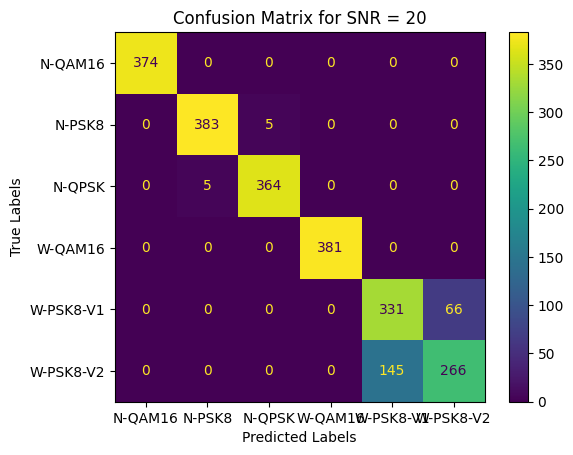

<Figure size 1600x800 with 0 Axes>

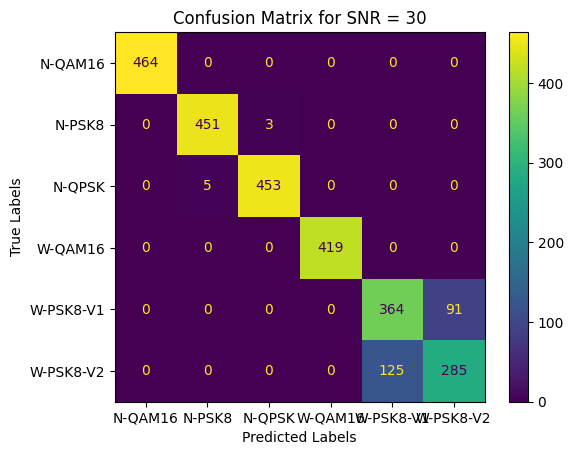

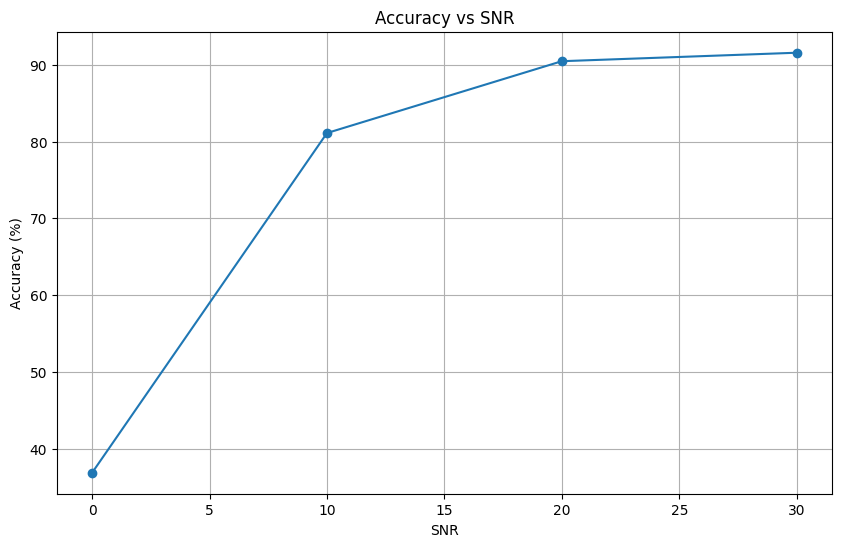

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: For a basic CNN model, we achieved an overall test accuracy of 75.36%. The accuracy shows a relationship with the SNR, as illustrated in the last graph. At SNR = 0, the model performs similarly across all classes, with no significant discrepancies. However, as the SNR increases, starting around SNR = 10, most classes show improved recognition accuracy except for classes 4 and 5, which continue to face difficulties.

## Experiment 3: Deeper CNN

Let's build a deeper CNN. This will help get a greater receptive field of the signal by using more pooling operations

In [ ]:
class CNNDeeperModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(2, 32, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.norm2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.norm3 = nn.BatchNorm1d(128)
        self.conv4 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.norm4 = nn.BatchNorm1d(256)

        self.pool = nn.MaxPool1d(kernel_size=4)
        self.dropout = nn.Dropout(0.5)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(256 * 8, 6)

    def forward(self, x):
        # [B, C, T]
        x = torch.transpose(x,1, 2) # [B, T, C]

        x = F.relu(self.norm1(self.conv1(x)))  # [B, 32, C]
        x = self.pool(x)          # [B, 32, C/4]

        x = F.relu(self.norm2(self.conv2(x)))  # [B, 64, C/4]
        x = self.pool(x)  # [B, 64, C/16]

        x = F.relu(self.norm3(self.conv3(x)))  # [B, 128, C/16]
        x = self.pool(x)  # [B, 128, C/64]

        x = F.relu(self.norm4(self.conv4(x)))  # [B, 256, C/64]
        x = self.pool(x) # [B, 256, C/64*4]
        x = self.dropout(x)
        # Flatten for fully connected layer
        x = self.flatten(x)        # [B, 256, 8] -> [B, 256 * 8]
        x = self.fc(x)             # [B, 6]

        return F.log_softmax(x, dim=1)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = CNNDeeperModel().to(device)
config = Config(epochs=50, experiment_dir="cnn_deeper_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/50

Train set: Average Loss: 0.953229, Accuracy: 16008/30000 (53.36%)
Validation set: Average Loss: 0.711644, Accuracy: 6342/10000 (63.42%)
New best model saved with validation accuracy: 63.42%
----------------------------------------------------------------------------------------------------
Epoch 2/50

Train set: Average Loss: 0.709947, Accuracy: 18257/30000 (60.86%)
Validation set: Average Loss: 2.086631, Accuracy: 4211/10000 (42.11%)
----------------------------------------------------------------------------------------------------
Epoch 3/50

Train set: Average Loss: 0.624827, Accuracy: 20050/30000 (66.83%)
Validation set: Average Loss: 0.534537, Accuracy: 7206/10000 (72.06%)
New best model saved with validation accuracy: 72.06%
----------------------------------------------------------------------------------------------------
Epoch 4/50

Train set: Average Loss: 0.530370, Accuracy: 21993/30000 (73.31%)
Validation set: Average Loss: 1.861620, Accuracy: 6127/10000 (61.27

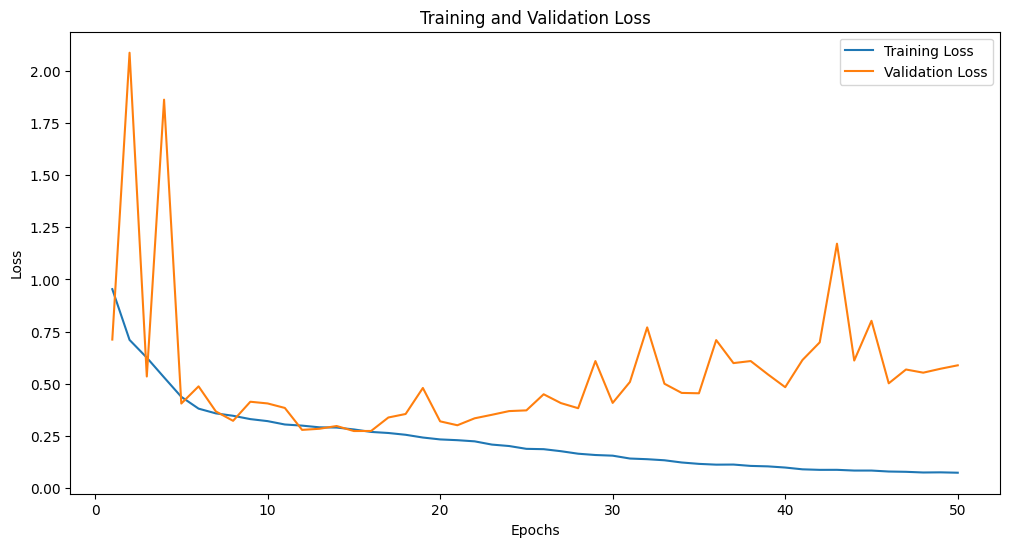

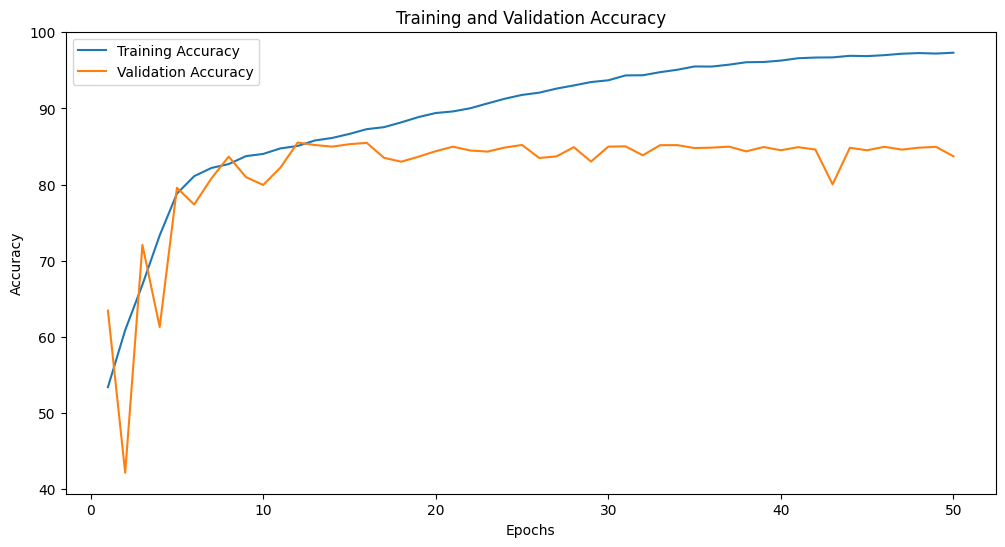

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 0.276302, Accuracy: 8543/10000 (85.43%)
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1697
           1       0.95      0.75      0.84      1650
           2       0.80      0.89      0.84      1653
           3       0.88      0.85      0.87      1653
           4       0.74      0.93      0.83      1684
           5       0.99      0.75      0.85      1663

    accuracy                           0.85     10000
   macro avg       0.87      0.85      0.85     10000
weighted avg       0.87      0.85      0.85     10000



<Figure size 1600x800 with 0 Axes>

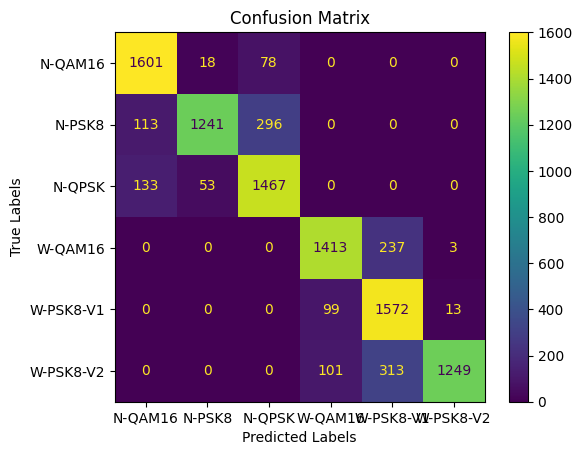

<Figure size 1600x800 with 0 Axes>

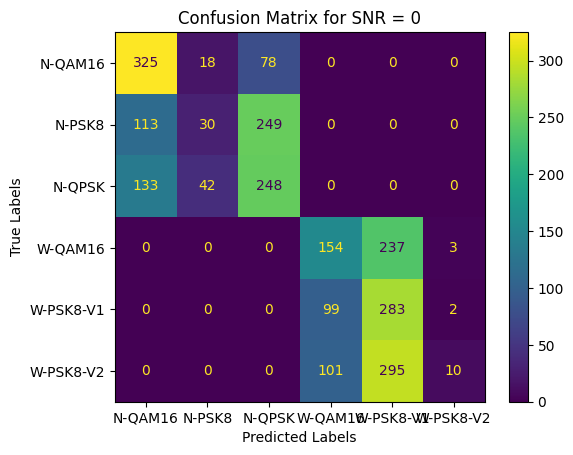

<Figure size 1600x800 with 0 Axes>

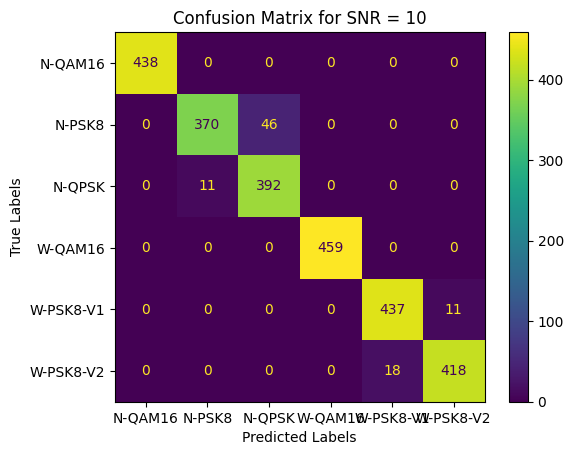

<Figure size 1600x800 with 0 Axes>

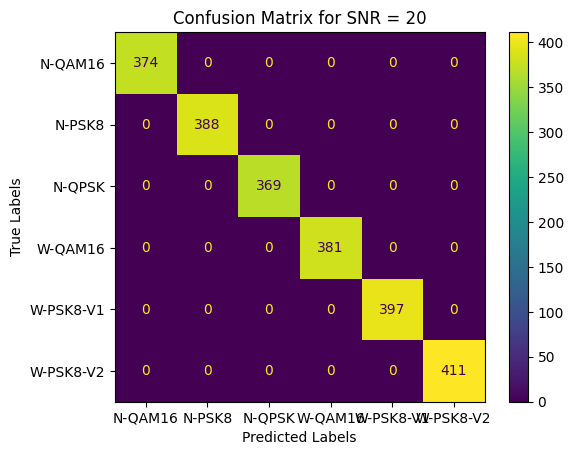

<Figure size 1600x800 with 0 Axes>

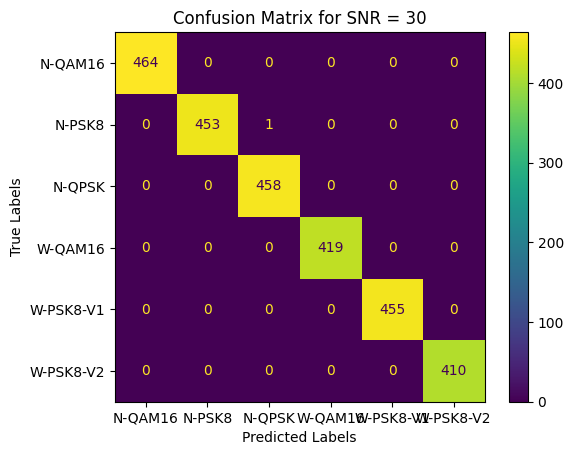

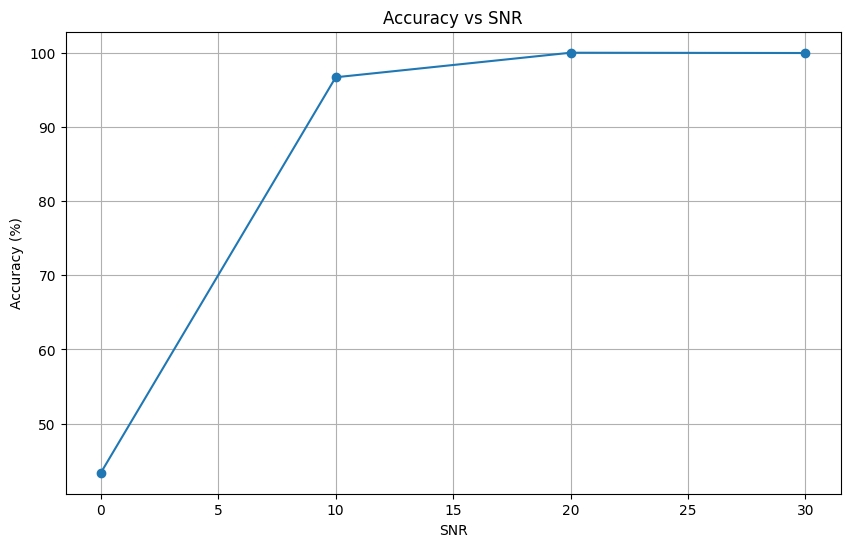

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: With a more complex CNN model, we achieved a test accuracy of 85.43%. This deeper network performs almost perfectly starting from an SNR of 10, with almost no remaining issues for classes 4 and 5. There is a huge difference in performance between SNR = 0 and higher SNR levels. It highlights the impact of signal quality on model accuracy.

## Experiment 4: Bi-Directional LSTM

Recurrent Neural Network are often used in sequential data such as NLP or signal data. In this experiment we will use a bidirectional LSTM layer.

In [ ]:
class BasicLSTMModel(nn.Module):
    def __init__(self, hidden_size, num_layers, bidrectional):

        super(BasicLSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size=2048, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, bidirectional= bidrectional)  # Input: [B, T, C]
        self.flatten = nn.Flatten()
        if bidrectional:
            self.fc = nn.Linear(4*hidden_size, 6)
        else:
            self.fc = nn.Linear(2*hidden_size, 6)

    def forward(self, x):
        # [B, C, T] -> [B, T, C]
        x = torch.transpose(x, 1, 2)
        # LSTM output
        out, _ = self.lstm(x)  # [B, T, hidden_size] / [B, T, 2*hidden_size]
        out = self.flatten(out)  # [B, hidden_size * T] / [B, T, 2*hidden_size]
        # Fully connected layer
        out = self.fc(out)  # [B, 6]

        return F.log_softmax(out, dim=1)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = BasicLSTMModel(128, 8,True).to(device)
config = Config(experiment_dir="bi_lstm_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/20

Train set: Average Loss: 1.516680, Accuracy: 7861/30000 (26.20%)
Validation set: Average Loss: 1.328645, Accuracy: 3138/10000 (31.38%)
New best model saved with validation accuracy: 31.38%
----------------------------------------------------------------------------------------------------
Epoch 2/20

Train set: Average Loss: 1.151655, Accuracy: 9877/30000 (32.92%)
Validation set: Average Loss: 1.314845, Accuracy: 2982/10000 (29.82%)
----------------------------------------------------------------------------------------------------
Epoch 3/20

Train set: Average Loss: 1.119845, Accuracy: 10104/30000 (33.68%)
Validation set: Average Loss: 1.363123, Accuracy: 3007/10000 (30.07%)
----------------------------------------------------------------------------------------------------
Epoch 4/20

Train set: Average Loss: 1.143987, Accuracy: 10343/30000 (34.48%)
Validation set: Average Loss: 1.410375, Accuracy: 3055/10000 (30.55%)
-----------------------------------------------------

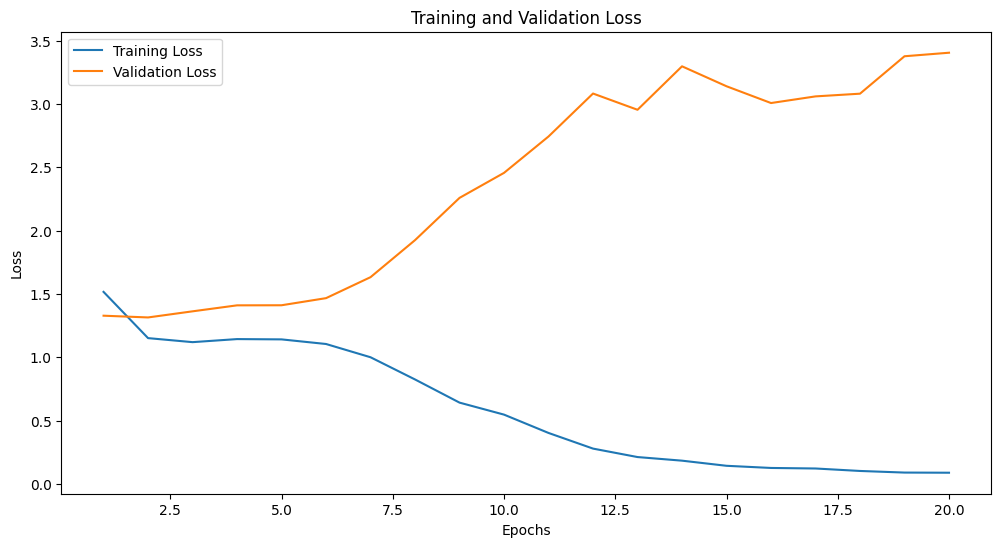

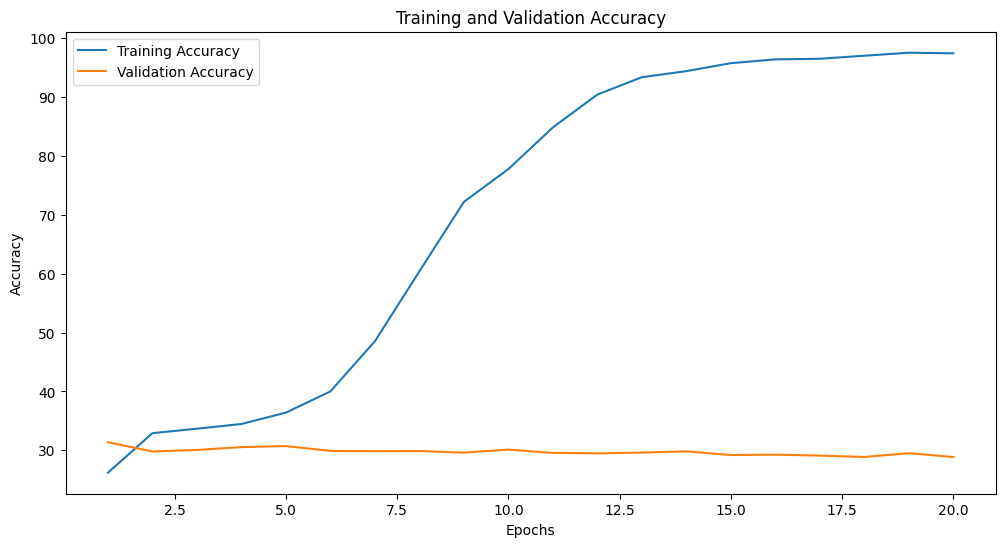

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 1.323157, Accuracy: 3120/10000 (31.20%)
              precision    recall  f1-score   support

           0       0.25      0.09      0.13      1697
           1       0.32      0.83      0.46      1650
           2       0.19      0.02      0.04      1653
           3       0.00      0.00      0.00      1653
           4       0.33      0.88      0.48      1684
           5       0.19      0.05      0.08      1663

    accuracy                           0.31     10000
   macro avg       0.21      0.31      0.20     10000
weighted avg       0.21      0.31      0.20     10000



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1600x800 with 0 Axes>

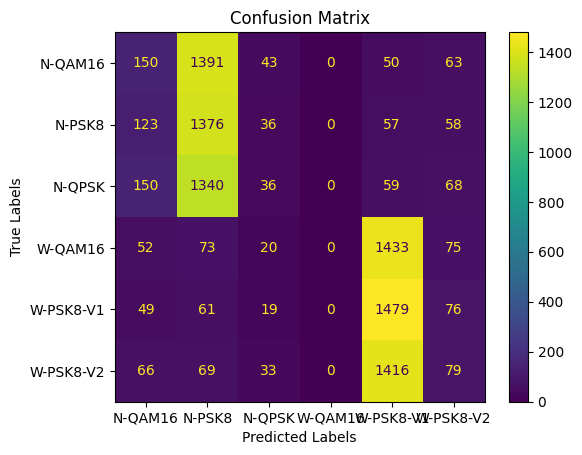

<Figure size 1600x800 with 0 Axes>

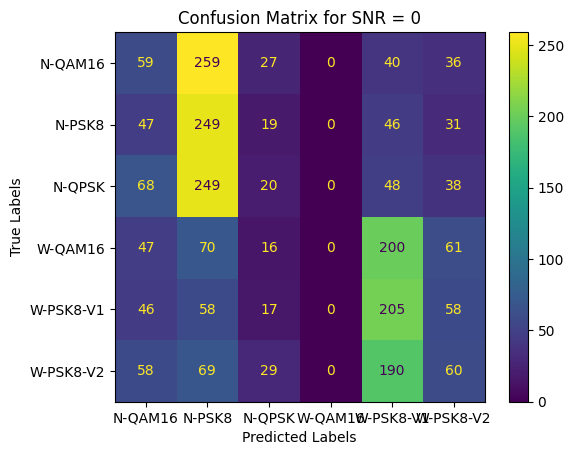

<Figure size 1600x800 with 0 Axes>

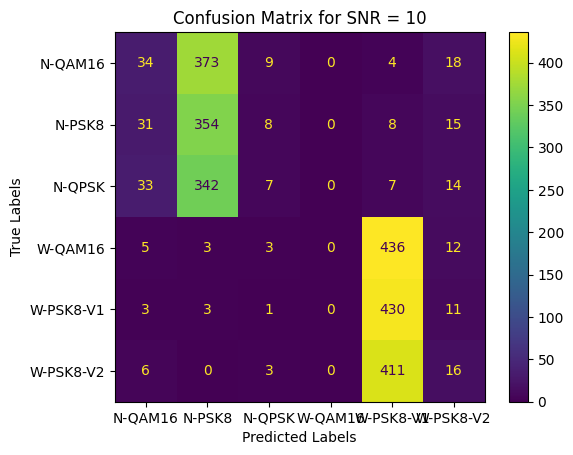

<Figure size 1600x800 with 0 Axes>

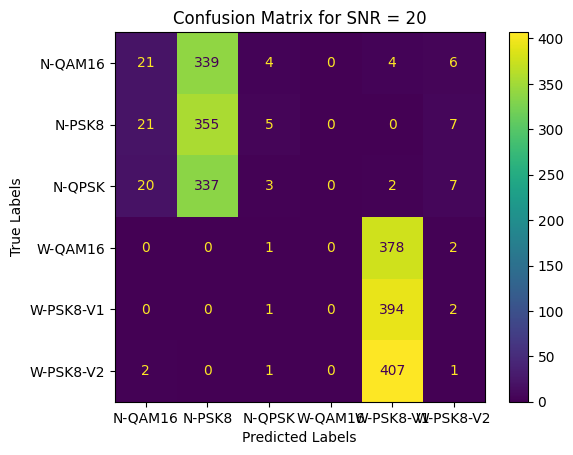

<Figure size 1600x800 with 0 Axes>

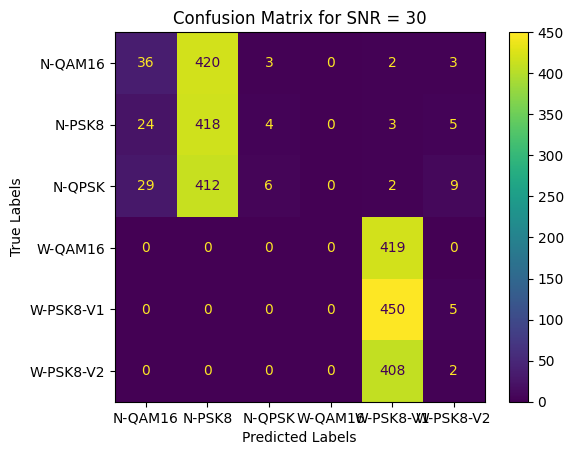

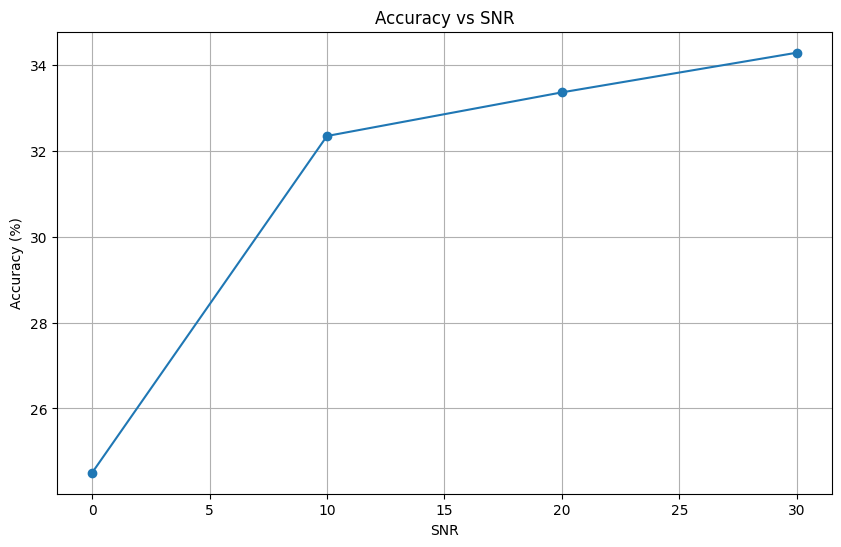

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: With the Bi-Directional LSTM model, we achieved a test accuracy of 31.20%, demonstrating that the model is far too simple for this task. As with the previous models, performance is particularly poor at SNR = 0, while it improves significantly as the SNR increases.

## Experiment 5: Uni-Directional LSTM

Recurrent Neural Network are often used in sequential data such as NLP or signal data. In this experiment we will use only the forward LSTM layer.

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = BasicLSTMModel(128, 8, False).to(device)
config = Config(experiment_dir="uni_lstm_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/20

Train set: Average Loss: 1.676899, Accuracy: 6534/30000 (21.78%)
Validation set: Average Loss: 1.411738, Accuracy: 2895/10000 (28.95%)
New best model saved with validation accuracy: 28.95%
----------------------------------------------------------------------------------------------------
Epoch 2/20

Train set: Average Loss: 1.235105, Accuracy: 9600/30000 (32.00%)
Validation set: Average Loss: 1.344543, Accuracy: 2972/10000 (29.72%)
New best model saved with validation accuracy: 29.72%
----------------------------------------------------------------------------------------------------
Epoch 3/20

Train set: Average Loss: 1.109177, Accuracy: 10350/30000 (34.50%)
Validation set: Average Loss: 1.511520, Accuracy: 2971/10000 (29.71%)
----------------------------------------------------------------------------------------------------
Epoch 4/20

Train set: Average Loss: 1.099964, Accuracy: 11827/30000 (39.42%)
Validation set: Average Loss: 1.506580, Accuracy: 2915/10000 (29.15%)

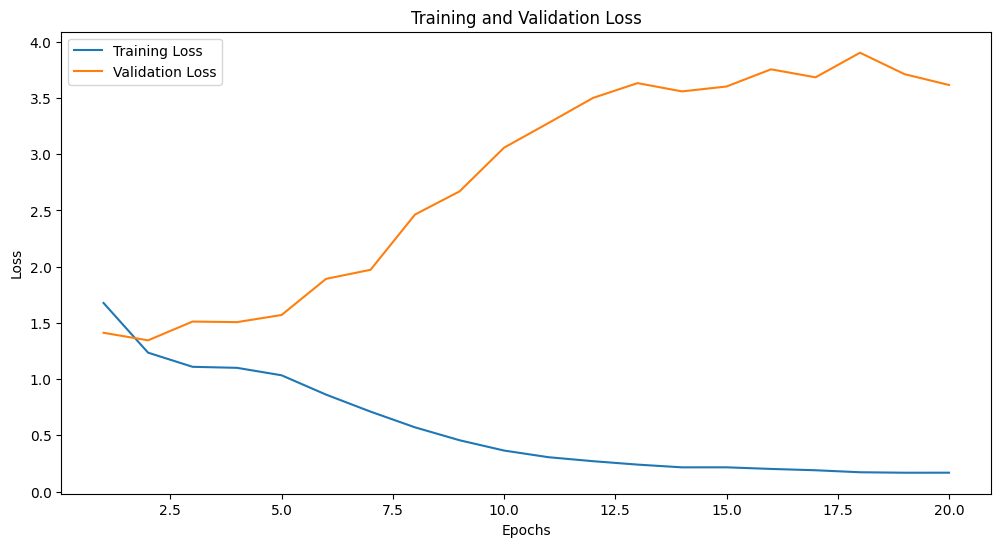

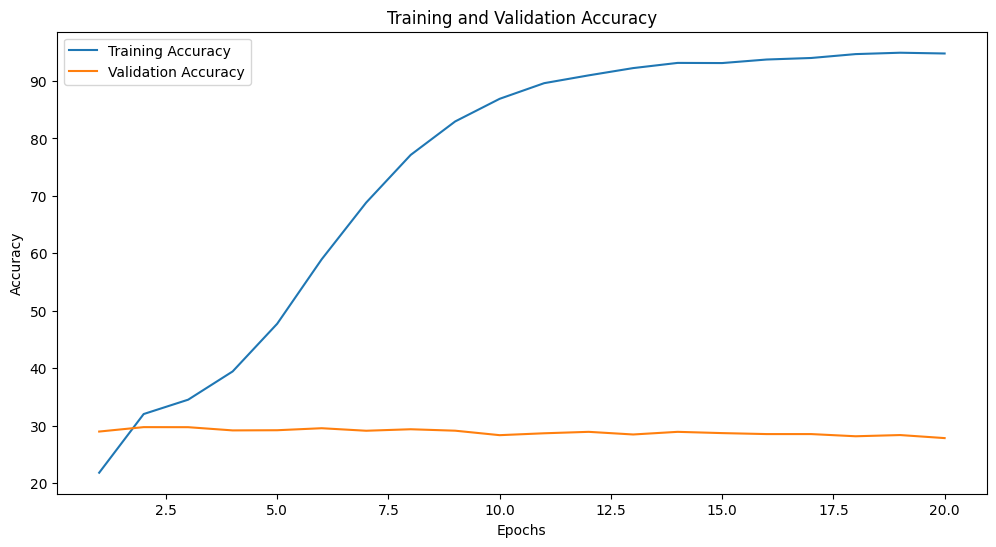

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 1.352890, Accuracy: 2981/10000 (29.81%)
              precision    recall  f1-score   support

           0       0.32      0.64      0.43      1697
           1       0.26      0.24      0.25      1650
           2       0.30      0.04      0.07      1653
           3       0.00      0.00      0.00      1653
           4       0.32      0.23      0.27      1684
           5       0.29      0.63      0.39      1663

    accuracy                           0.30     10000
   macro avg       0.25      0.30      0.23     10000
weighted avg       0.25      0.30      0.24     10000



<Figure size 1600x800 with 0 Axes>

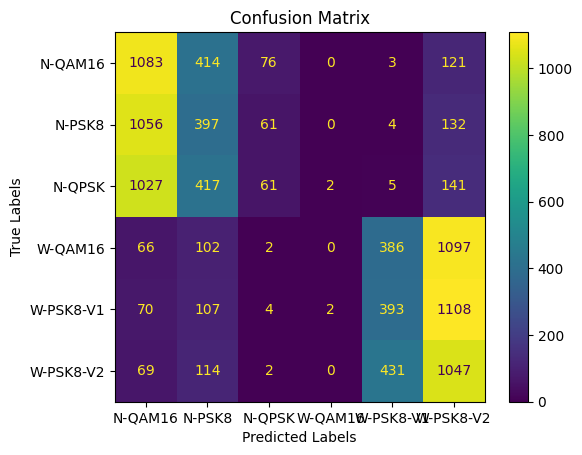

<Figure size 1600x800 with 0 Axes>

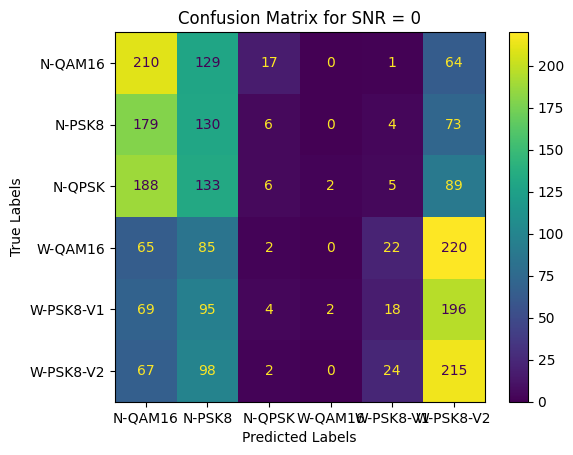

<Figure size 1600x800 with 0 Axes>

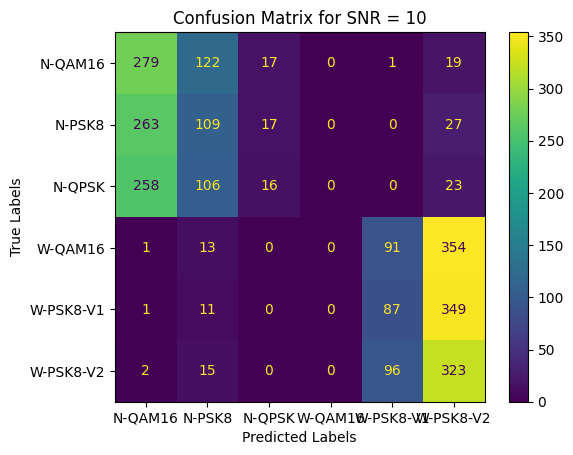

<Figure size 1600x800 with 0 Axes>

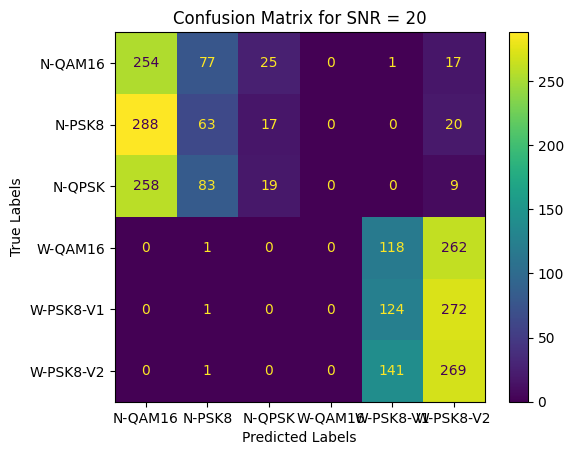

<Figure size 1600x800 with 0 Axes>

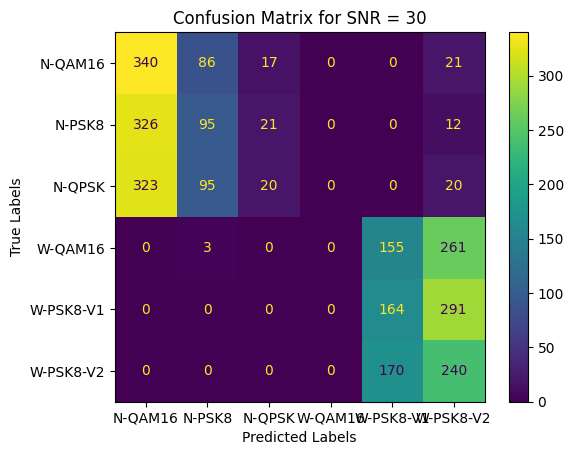

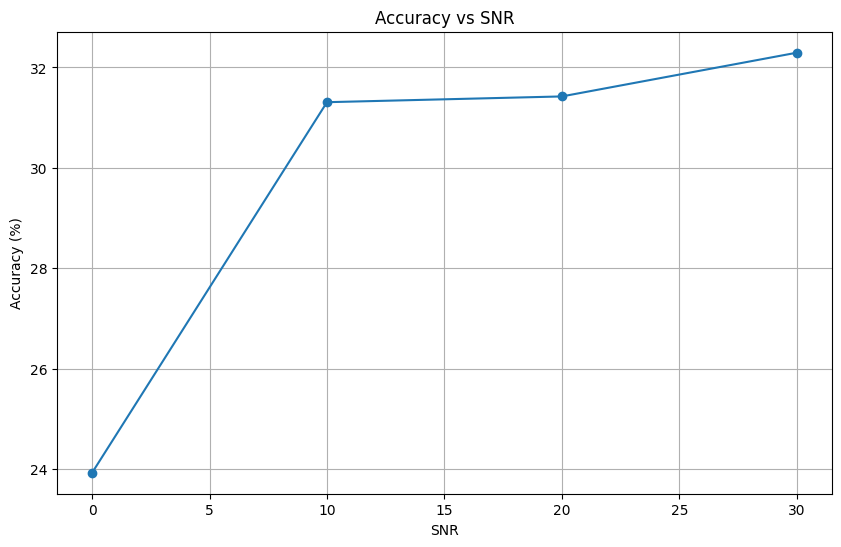

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: With the Uni-Directional LSTM model, we achieved a test accuracy of 29.81%, showing similar limitations to the Bi-Directional LSTM.

## Experiment 6: Combining CNN and LSTM

We will first use CNN to extract some features about the signal, then use an LSTM before the linear prediction head.

In [ ]:
class CNNLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(2, 32, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.norm2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.norm3 = nn.BatchNorm1d(128)
        self.conv4 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.norm4 = nn.BatchNorm1d(256)
        self.pool = nn.MaxPool1d(kernel_size=4)

        self.dropout = nn.Dropout(0.5)
        self.lstm = nn.LSTM(input_size=8, hidden_size=128, num_layers=6, batch_first=True, bidirectional= False)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(256 * 128, 6)

    def forward(self, x):
        # [B, C, T]
        x = torch.transpose(x,1, 2) # [B, T, C]

        x = F.relu(self.norm1(self.conv1(x)))  # [B, 32, C]
        x = self.pool(x)          # [B, 32, C/4]

        x = F.relu(self.norm2(self.conv2(x)))  # [B, 64, C/4]
        x = self.pool(x)  # [B, 64, C/16]

        x = F.relu(self.norm3(self.conv3(x)))  # [B, 128, C/16]
        x = self.pool(x)  # [B, 128, C/64]

        x = F.relu(self.norm4(self.conv4(x)))  # [B, 256, C/64]
        x = self.pool(x) # [B, 256, 8]


        x, _ = self.lstm(x)  # [B, 256, hidden_size]
        x = self.dropout(x)

        # Flatten for fully connected layer
        x = self.flatten(x)        # [B, 256, 128] -> [B, 256 * 128]
        x = self.fc(x)             # [B, 6]

        return F.log_softmax(x, dim=1)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# hidden_size = 128 , num_layers = 6, bidrectional = False
model = CNNLSTMModel().to(device)
config = Config(epochs=30, experiment_dir="cnnlstm_model")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/30

Train set: Average Loss: 0.922690, Accuracy: 14969/30000 (49.90%)
Validation set: Average Loss: 0.664124, Accuracy: 5837/10000 (58.37%)
New best model saved with validation accuracy: 58.37%
----------------------------------------------------------------------------------------------------
Epoch 2/30

Train set: Average Loss: 0.676143, Accuracy: 17535/30000 (58.45%)
Validation set: Average Loss: 0.627962, Accuracy: 5936/10000 (59.36%)
New best model saved with validation accuracy: 59.36%
----------------------------------------------------------------------------------------------------
Epoch 3/30

Train set: Average Loss: 0.646542, Accuracy: 18259/30000 (60.86%)
Validation set: Average Loss: 0.580768, Accuracy: 6534/10000 (65.34%)
New best model saved with validation accuracy: 65.34%
----------------------------------------------------------------------------------------------------
Epoch 4/30

Train set: Average Loss: 0.596774, Accuracy: 19828/30000 (66.09%)
Validation se

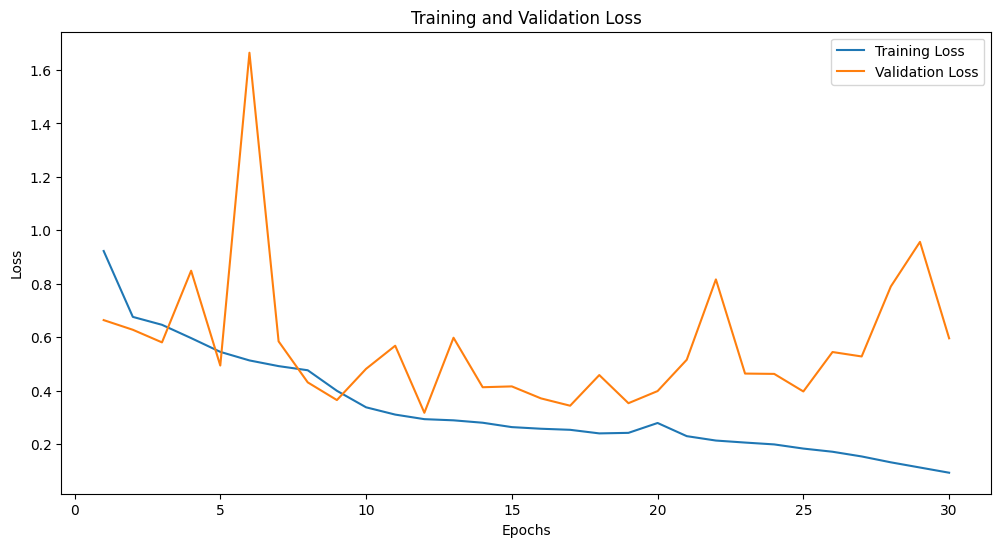

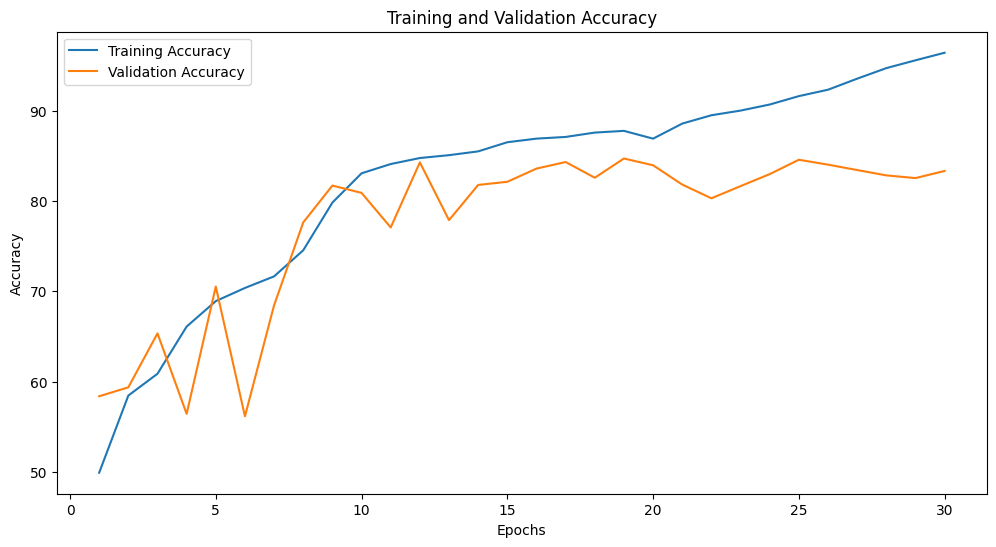

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 0.343322, Accuracy: 8483/10000 (84.83%)
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1697
           1       0.87      0.81      0.83      1650
           2       0.83      0.81      0.82      1653
           3       0.84      0.88      0.86      1653
           4       0.87      0.82      0.85      1684
           5       0.84      0.85      0.84      1663

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



<Figure size 1600x800 with 0 Axes>

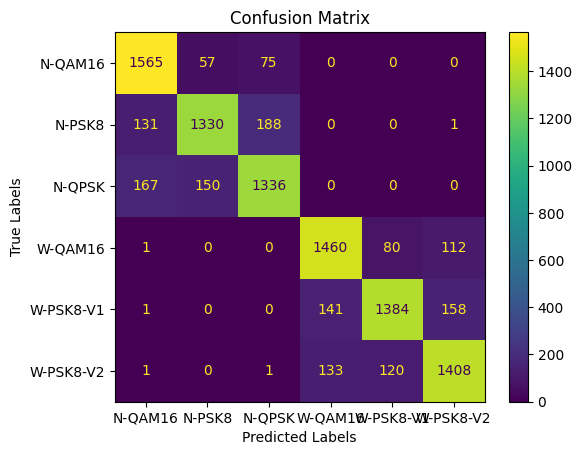

<Figure size 1600x800 with 0 Axes>

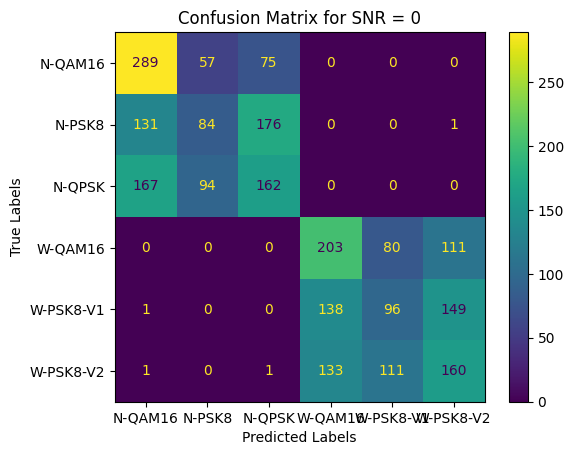

<Figure size 1600x800 with 0 Axes>

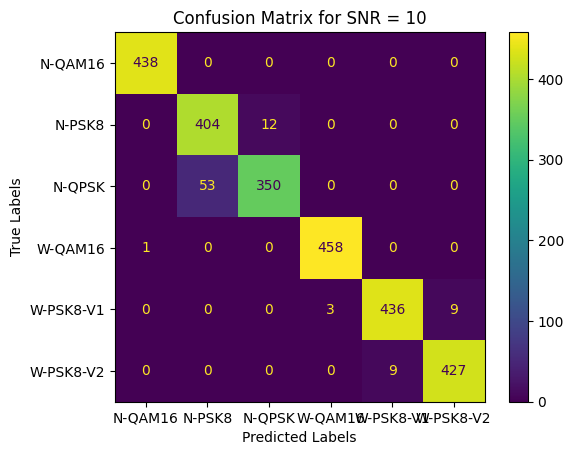

<Figure size 1600x800 with 0 Axes>

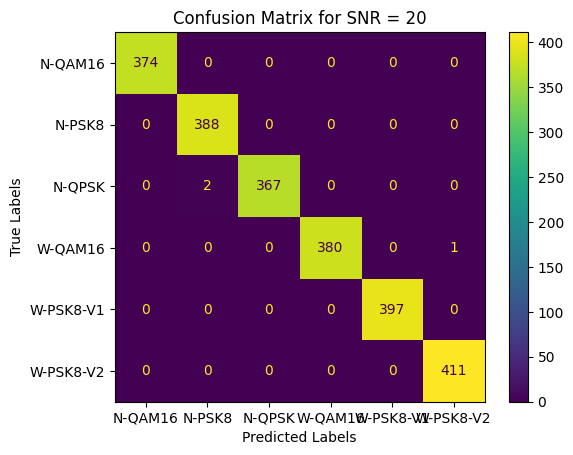

<Figure size 1600x800 with 0 Axes>

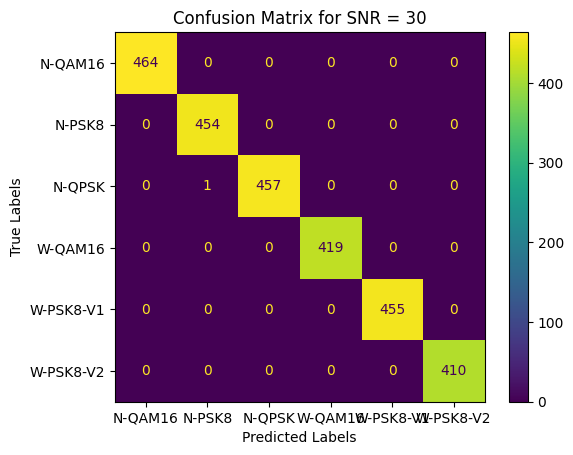

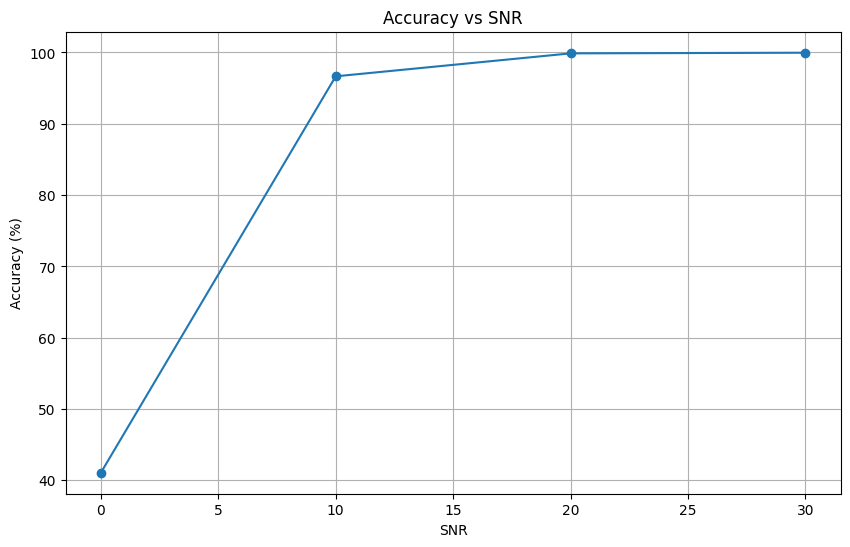

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: With the combined CNN and LSTM model, we achieved a test accuracy of 84.83%, delivering results similar to the deeper CNN model. The performance is nearly perfect from SNR = 10 and there are no longer difficulties with classes 4 and 5.

## Experiment 7: Adding data augmentation

Based on the previous experiment we will kept the model from **experiment 3** and retrain it using data augmentation following the approach the author did in this paper [https://arxiv.org/pdf/1912.03026](https://arxiv.org/pdf/1912.03026): .

In [ ]:
import random

def apply_random(fn, p=0.5):
    def wrapper(signal):
        if random.random() > (1 - p):
            return fn(signal)
        return signal
    return wrapper

def horizontal_flip(signal):
    signal[:, 0] = -signal[:, 0]
    return signal

def vertical_flip(signal):
    signal[:, 1] = -signal[:, 1]
    return signal

def random_rotation(signal):
    possible_rotations = [0, np.pi / 2, np.pi, 3 * np.pi / 2]

    theta = possible_rotations[random.randint(0, len(possible_rotations)-1)]
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    signal = (rotation_matrix @ signal.T).T.astype(np.float32)

    return signal

class DatasetWithAugmentation(torch.utils.data.Dataset):
    def __init__(self, path_to_data):
        with h5py.File(path_to_data, 'r') as data:
          self.signals = np.array(data['signaux'])
          self.snr = np.array(data['snr'])
          self.labels_id = np.array(data['labels'])

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signals = self.signals[idx]
        snr = self.snr[idx]
        labels_id = self.labels_id[idx]

        signals = apply_random(horizontal_flip)(signals)
        signals = apply_random(vertical_flip)(signals)
        signals = apply_random(random_rotation)(signals)

        return signals, snr, labels_id

In [ ]:
from torch.utils.data import DataLoader

train_dataset = DatasetWithAugmentation(TRAIN_PATH)
valid_dataset = MyDataset(VALIDATION_PATH)
test_dataset = MyDataset(TEST_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = CNNDeeperModel().to(device)
config = Config(epochs=50, experiment_dir="cnnlstm_model_with_augmentation")
trainer = Trainer(model, config)

In [ ]:
trainer.train(train_dataloader, valid_dataloader)

Epoch 1/50

Train set: Average Loss: 0.922088, Accuracy: 16401/30000 (54.67%)
Validation set: Average Loss: 0.647365, Accuracy: 5977/10000 (59.77%)
New best model saved with validation accuracy: 59.77%
----------------------------------------------------------------------------------------------------
Epoch 2/50

Train set: Average Loss: 0.697426, Accuracy: 18771/30000 (62.57%)
Validation set: Average Loss: 0.665533, Accuracy: 6201/10000 (62.01%)
New best model saved with validation accuracy: 62.01%
----------------------------------------------------------------------------------------------------
Epoch 3/50

Train set: Average Loss: 0.595687, Accuracy: 20388/30000 (67.96%)
Validation set: Average Loss: 0.989643, Accuracy: 6112/10000 (61.12%)
----------------------------------------------------------------------------------------------------
Epoch 4/50

Train set: Average Loss: 0.515717, Accuracy: 22179/30000 (73.93%)
Validation set: Average Loss: 0.396288, Accuracy: 7985/10000 (79.85

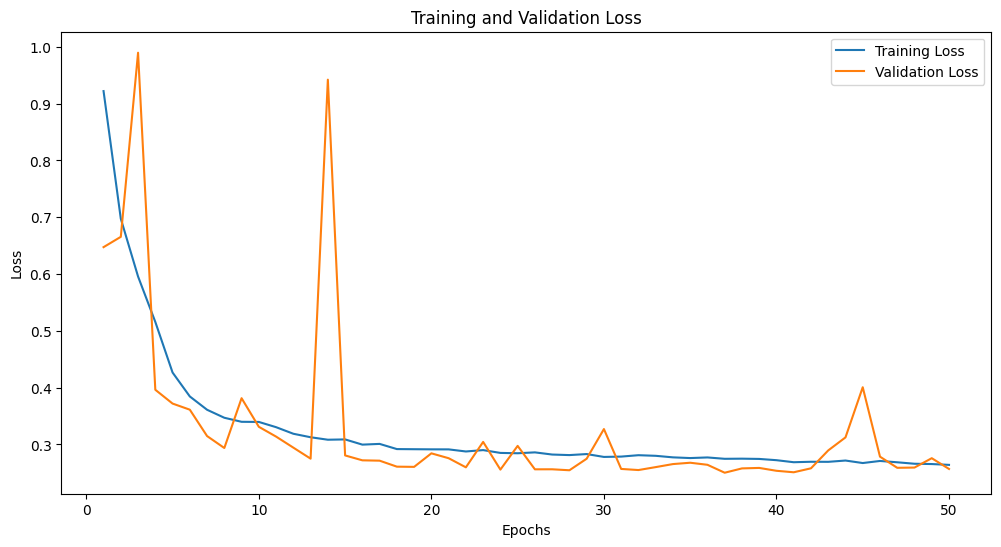

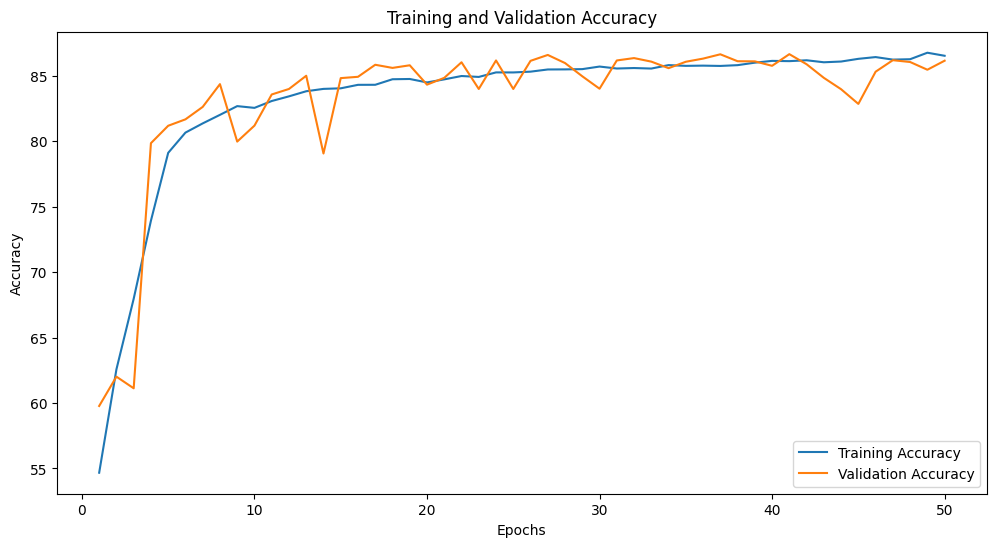

In [ ]:
trainer.plot_training_curves()

<ipython-input-39-3eb57ac64e45>:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(self.best_model_path))


Test set: Average Loss: 0.246909, Accuracy: 8690/10000 (86.90%)
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1697
           1       0.81      0.92      0.86      1650
           2       0.94      0.79      0.86      1653
           3       0.89      0.85      0.87      1653
           4       0.78      0.91      0.84      1684
           5       0.92      0.81      0.86      1663

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



<Figure size 1600x800 with 0 Axes>

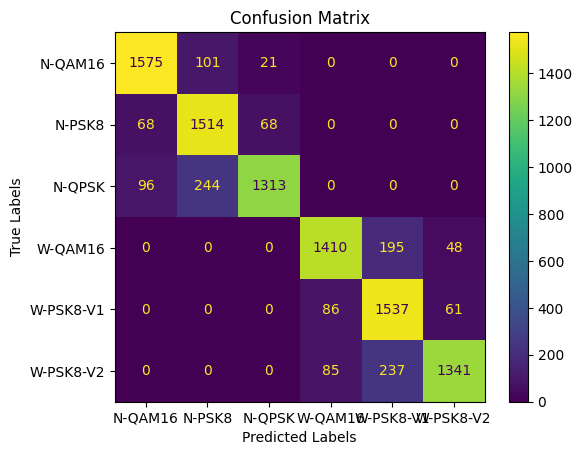

<Figure size 1600x800 with 0 Axes>

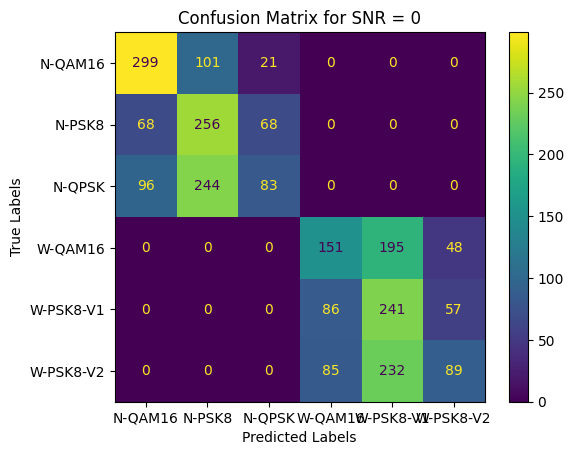

<Figure size 1600x800 with 0 Axes>

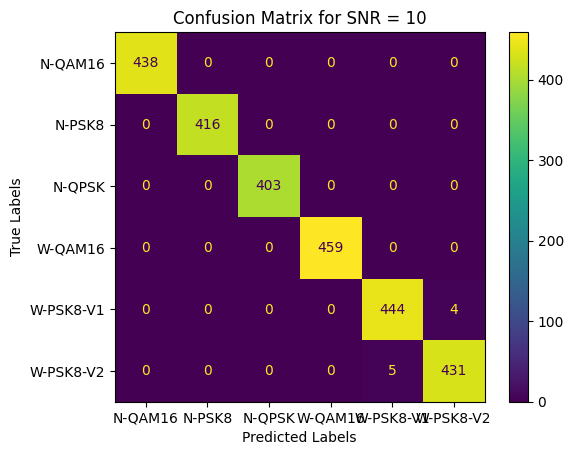

<Figure size 1600x800 with 0 Axes>

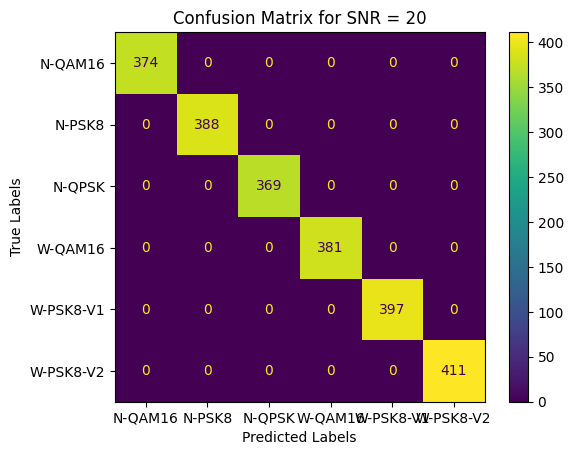

<Figure size 1600x800 with 0 Axes>

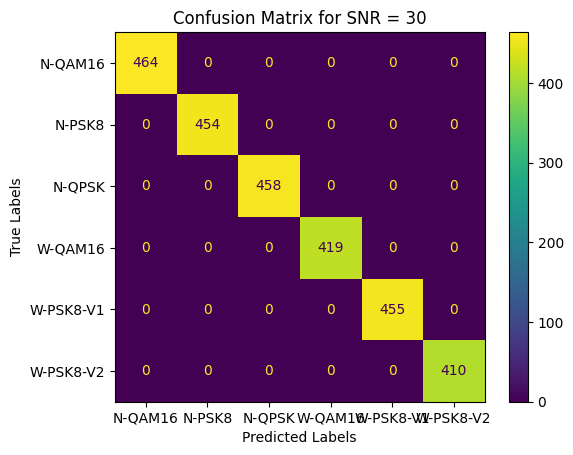

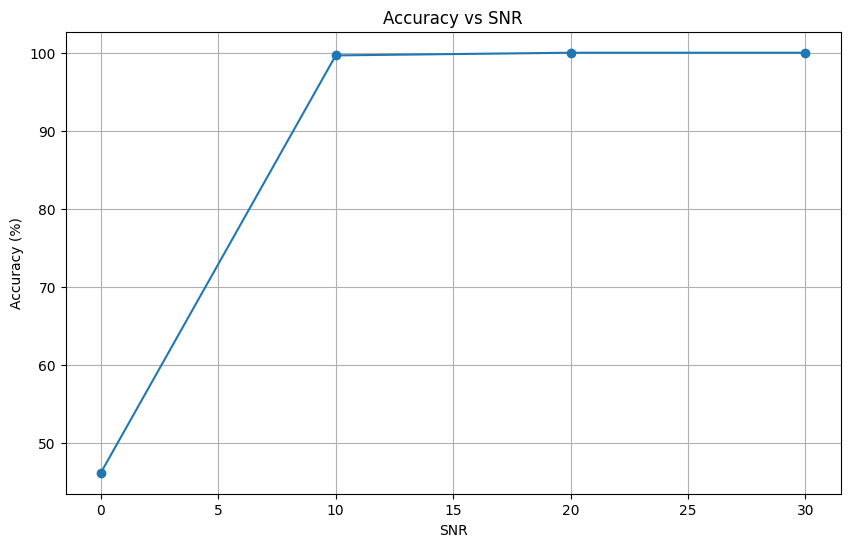

In [ ]:
trainer.test(test_dataloader)

**Conclusion**: With the combined CNN and LSTM model plus data augmentation, we achieved a test accuracy of 86.90%, which is only a small improvement over the previous model.

# Conclusion

| Experiment   |      Approach      |  Global Accuracy |
|----------|-------------|------|
| 1 |  Simple | 18.06% |
| 2 |    CNN   |   75.36% |
| 3 | Deeper CNN |    85.43% |
| 4 | Bi-Directional LSTM |    31.20% |
| 5 | Uni-Directional LSTM |    29.81% |
| 6 | CNN & LSTM |    84.83% |
| 7 | CNN & LSTM + Data Augmentation |    86.90% |


Based on the above tables, and the details per class and SNR computed above, the models CNN & LSTM + Data Augmentation, CNN & LSTM, and Deeper CNN achieve roughly similar results in terms of global accuracy. The real issue lies with SNR = 0, where all models struggle, achieving less than 50% accuracy, while for SNR = 10, 20, and 30, the accuracy is nearly 100%. This underscores how much noise affects model performance and points to the need for strategies better suited to dealing with noisy signals. One option could be to add more data augmentation that simulates noisy conditions, which might help the models perform better in challenging cases like SNR = 0.